# Steered

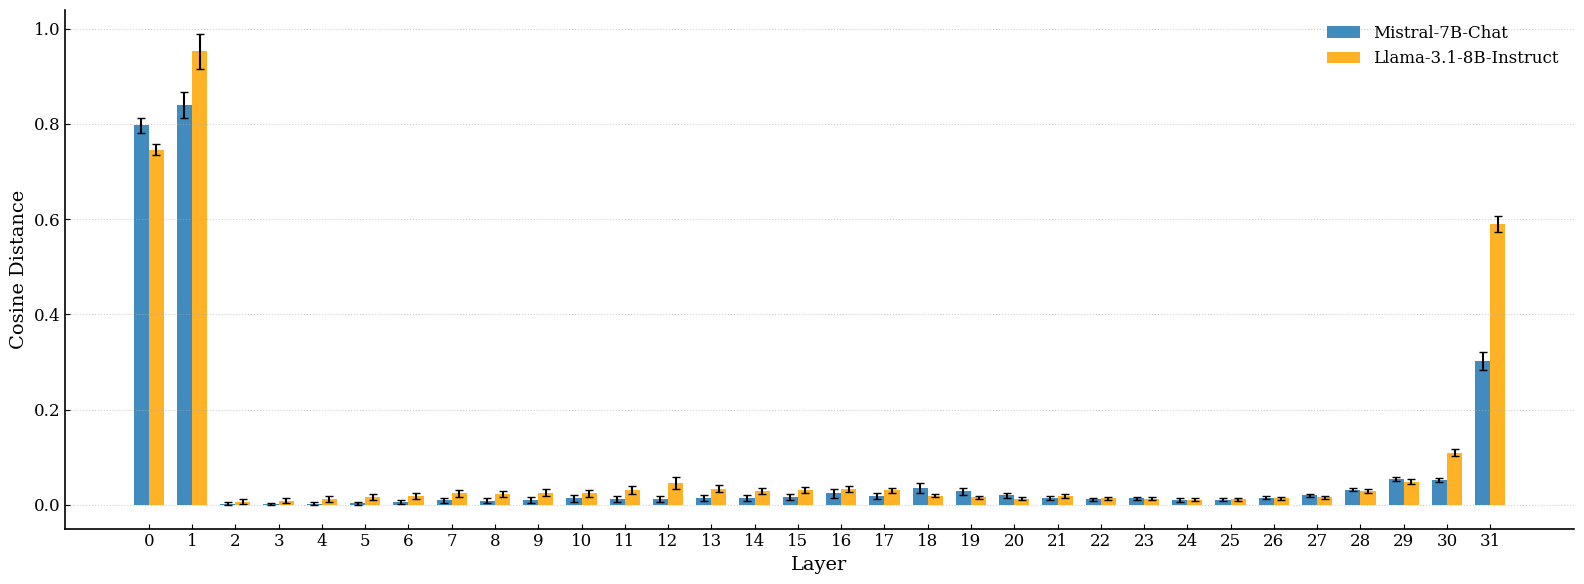

In [352]:
import matplotlib.pyplot as plt
import numpy as np
import re

# Your raw text data
mistral_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0162
[Layer:] 1 | Cosine Distance [Mean:] 0.8398 [Std:] 0.0272
[Layer:] 2 | Cosine Distance [Mean:] 0.0020 [Std:] 0.0027
[Layer:] 3 | Cosine Distance [Mean:] 0.0015 [Std:] 0.0020
[Layer:] 4 | Cosine Distance [Mean:] 0.0021 [Std:] 0.0027
[Layer:] 5 | Cosine Distance [Mean:] 0.0031 [Std:] 0.0034
[Layer:] 6 | Cosine Distance [Mean:] 0.0054 [Std:] 0.0046
[Layer:] 7 | Cosine Distance [Mean:] 0.0088 [Std:] 0.0054
[Layer:] 8 | Cosine Distance [Mean:] 0.0087 [Std:] 0.0053
[Layer:] 9 | Cosine Distance [Mean:] 0.0095 [Std:] 0.0056
[Layer:] 10 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0077
[Layer:] 11 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0067
[Layer:] 12 | Cosine Distance [Mean:] 0.0117 [Std:] 0.0067
[Layer:] 13 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0066
[Layer:] 14 | Cosine Distance [Mean:] 0.0130 [Std:] 0.0063
[Layer:] 15 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0067
[Layer:] 16 | Cosine Distance [Mean:] 0.0238 [Std:] 0.0092
[Layer:] 17 | Cosine Distance [Mean:] 0.0181 [Std:] 0.0064
[Layer:] 18 | Cosine Distance [Mean:] 0.0342 [Std:] 0.0105
[Layer:] 19 | Cosine Distance [Mean:] 0.0283 [Std:] 0.0074
[Layer:] 20 | Cosine Distance [Mean:] 0.0193 [Std:] 0.0056
[Layer:] 21 | Cosine Distance [Mean:] 0.0133 [Std:] 0.0040
[Layer:] 22 | Cosine Distance [Mean:] 0.0112 [Std:] 0.0037
[Layer:] 23 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0040
[Layer:] 24 | Cosine Distance [Mean:] 0.0098 [Std:] 0.0036
[Layer:] 25 | Cosine Distance [Mean:] 0.0102 [Std:] 0.0035
[Layer:] 26 | Cosine Distance [Mean:] 0.0150 [Std:] 0.0034
[Layer:] 27 | Cosine Distance [Mean:] 0.0198 [Std:] 0.0034
[Layer:] 28 | Cosine Distance [Mean:] 0.0315 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0542 [Std:] 0.0042
[Layer:] 30 | Cosine Distance [Mean:] 0.0527 [Std:] 0.0041
[Layer:] 31 | Cosine Distance [Mean:] 0.3027 [Std:] 0.0188
"""

llama_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0116
[Layer:] 1 | Cosine Distance [Mean:] 0.9531 [Std:] 0.0369
[Layer:] 2 | Cosine Distance [Mean:] 0.0063 [Std:] 0.0047
[Layer:] 3 | Cosine Distance [Mean:] 0.0086 [Std:] 0.0048
[Layer:] 4 | Cosine Distance [Mean:] 0.0125 [Std:] 0.0059
[Layer:] 5 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0065
[Layer:] 6 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0069
[Layer:] 7 | Cosine Distance [Mean:] 0.0237 [Std:] 0.0081
[Layer:] 8 | Cosine Distance [Mean:] 0.0219 [Std:] 0.0067
[Layer:] 9 | Cosine Distance [Mean:] 0.0253 [Std:] 0.0077
[Layer:] 10 | Cosine Distance [Mean:] 0.0242 [Std:] 0.0075
[Layer:] 11 | Cosine Distance [Mean:] 0.0308 [Std:] 0.0088
[Layer:] 12 | Cosine Distance [Mean:] 0.0459 [Std:] 0.0125
[Layer:] 13 | Cosine Distance [Mean:] 0.0337 [Std:] 0.0081
[Layer:] 14 | Cosine Distance [Mean:] 0.0286 [Std:] 0.0062
[Layer:] 15 | Cosine Distance [Mean:] 0.0309 [Std:] 0.0073
[Layer:] 16 | Cosine Distance [Mean:] 0.0339 [Std:] 0.0063
[Layer:] 17 | Cosine Distance [Mean:] 0.0298 [Std:] 0.0055
[Layer:] 18 | Cosine Distance [Mean:] 0.0189 [Std:] 0.0037
[Layer:] 19 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0036
[Layer:] 20 | Cosine Distance [Mean:] 0.0128 [Std:] 0.0032
[Layer:] 21 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0036
[Layer:] 22 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0030
[Layer:] 23 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0030
[Layer:] 24 | Cosine Distance [Mean:] 0.0106 [Std:] 0.0026
[Layer:] 25 | Cosine Distance [Mean:] 0.0111 [Std:] 0.0026
[Layer:] 26 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0030
[Layer:] 27 | Cosine Distance [Mean:] 0.0159 [Std:] 0.0033
[Layer:] 28 | Cosine Distance [Mean:] 0.0281 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0483 [Std:] 0.0050
[Layer:] 30 | Cosine Distance [Mean:] 0.1094 [Std:] 0.0075
[Layer:] 31 | Cosine Distance [Mean:] 0.5898 [Std:] 0.0167
"""

def parse_data(raw_text):
    means = []
    stds = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            # Extract Mean and Std using regex
            match = re.search(r'\[Mean:\] ([\d.]+) \[Std:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
                stds.append(float(match.group(2)))
    return means, stds

# Parse the data
m_means, m_stds = parse_data(mistral_data_raw)
l_means, l_stds = parse_data(llama_data_raw)

# X-axis locations and bar width
layers = np.arange(len(m_means))
width = 0.35

# Apply academic styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,              
    'axes.labelsize': 14,         
    'axes.titlesize': 14,
    'figure.figsize': (16.0, 6.0), # Wide figure to fit 32 layers side-by-side
    'axes.spines.top': False,     
    'axes.spines.right': False
})

fig, ax = plt.subplots()

# Create grouped bar charts with error bars. Note the `+ width/2` for LLaMA to prevent overlap.
rects1 = ax.bar(layers - width/2, m_means, width, yerr=m_stds, label='Mistral-7B-Chat', color='#1f77b4', capsize=3, alpha=0.85)
rects2 = ax.bar(layers + width/2, l_means, width, yerr=l_stds, label='Llama-3.1-8B-Instruct', color='orange', capsize=3, alpha=0.85)

# Formatting
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine Distance')
ax.set_xticks(layers)
ax.set_xticklabels(layers)
ax.grid(True, linestyle=':', alpha=0.6, axis='y')

# Render the legend without a box frame, positioned in the top left
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
# plt.savefig('cosine_distance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [353]:
# Your raw text data
mistral_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0102 | [Max:] 1.0117 [Min:] 0.9727 [Rel_Norm:] 0.46875
[Layer:] 1 | Cosine Distance [Mean:] 0.9707 [Std:] 0.0131 | [Max:] 0.9941 [Min:] 0.9141 [Rel_Norm:] 0.0223388671875
[Layer:] 2 | Cosine Distance [Mean:] 0.9551 [Std:] 0.0189 | [Max:] 0.9883 [Min:] 0.8867 [Rel_Norm:] 0.0211181640625
[Layer:] 3 | Cosine Distance [Mean:] 0.9531 [Std:] 0.0161 | [Max:] 0.9844 [Min:] 0.8633 [Rel_Norm:] 0.02117919921875
[Layer:] 4 | Cosine Distance [Mean:] 0.9512 [Std:] 0.0155 | [Max:] 0.9824 [Min:] 0.8516 [Rel_Norm:] 0.021484375
[Layer:] 5 | Cosine Distance [Mean:] 0.9473 [Std:] 0.0165 | [Max:] 0.9805 [Min:] 0.8477 [Rel_Norm:] 0.02288818359375
[Layer:] 6 | Cosine Distance [Mean:] 0.9453 [Std:] 0.0142 | [Max:] 0.9785 [Min:] 0.8574 [Rel_Norm:] 0.023193359375
[Layer:] 7 | Cosine Distance [Mean:] 0.9395 [Std:] 0.0166 | [Max:] 0.9785 [Min:] 0.8555 [Rel_Norm:] 0.0234375
[Layer:] 8 | Cosine Distance [Mean:] 0.9375 [Std:] 0.0190 | [Max:] 0.9785 [Min:] 0.8652 [Rel_Norm:] 0.0242919921875
[Layer:] 9 | Cosine Distance [Mean:] 0.9375 [Std:] 0.0180 | [Max:] 0.9766 [Min:] 0.8594 [Rel_Norm:] 0.0250244140625
[Layer:] 10 | Cosine Distance [Mean:] 0.9277 [Std:] 0.0209 | [Max:] 0.9727 [Min:] 0.8359 [Rel_Norm:] 0.0245361328125
[Layer:] 11 | Cosine Distance [Mean:] 0.9258 [Std:] 0.0232 | [Max:] 0.9727 [Min:] 0.8359 [Rel_Norm:] 0.0242919921875
[Layer:] 12 | Cosine Distance [Mean:] 0.9316 [Std:] 0.0147 | [Max:] 0.9707 [Min:] 0.8652 [Rel_Norm:] 0.0257568359375
[Layer:] 13 | Cosine Distance [Mean:] 0.9395 [Std:] 0.0162 | [Max:] 0.9727 [Min:] 0.8652 [Rel_Norm:] 0.025146484375
[Layer:] 14 | Cosine Distance [Mean:] 0.9316 [Std:] 0.0168 | [Max:] 0.9688 [Min:] 0.8711 [Rel_Norm:] 0.022705078125
[Layer:] 15 | Cosine Distance [Mean:] 0.9258 [Std:] 0.0175 | [Max:] 0.9688 [Min:] 0.8711 [Rel_Norm:] 0.02252197265625
[Layer:] 16 | Cosine Distance [Mean:] 0.9277 [Std:] 0.0152 | [Max:] 0.9668 [Min:] 0.8828 [Rel_Norm:] 0.0224609375
[Layer:] 17 | Cosine Distance [Mean:] 0.9453 [Std:] 0.0174 | [Max:] 0.9883 [Min:] 0.8867 [Rel_Norm:] 0.02142333984375
[Layer:] 18 | Cosine Distance [Mean:] 0.9316 [Std:] 0.0138 | [Max:] 0.9648 [Min:] 0.8906 [Rel_Norm:] 0.020751953125
[Layer:] 19 | Cosine Distance [Mean:] 0.9375 [Std:] 0.0120 | [Max:] 0.9688 [Min:] 0.9004 [Rel_Norm:] 0.018310546875
[Layer:] 20 | Cosine Distance [Mean:] 0.9355 [Std:] 0.0110 | [Max:] 0.9648 [Min:] 0.8984 [Rel_Norm:] 0.01690673828125
[Layer:] 21 | Cosine Distance [Mean:] 0.9297 [Std:] 0.0116 | [Max:] 0.9609 [Min:] 0.8906 [Rel_Norm:] 0.0159912109375
[Layer:] 22 | Cosine Distance [Mean:] 0.9219 [Std:] 0.0181 | [Max:] 0.9590 [Min:] 0.8672 [Rel_Norm:] 0.01531982421875
[Layer:] 23 | Cosine Distance [Mean:] 0.9219 [Std:] 0.0148 | [Max:] 0.9551 [Min:] 0.8750 [Rel_Norm:] 0.01470947265625
[Layer:] 24 | Cosine Distance [Mean:] 0.9082 [Std:] 0.0207 | [Max:] 0.9512 [Min:] 0.8633 [Rel_Norm:] 0.01397705078125
[Layer:] 25 | Cosine Distance [Mean:] 0.9102 [Std:] 0.0197 | [Max:] 0.9492 [Min:] 0.8516 [Rel_Norm:] 0.013458251953125
[Layer:] 26 | Cosine Distance [Mean:] 0.9160 [Std:] 0.0112 | [Max:] 0.9453 [Min:] 0.8750 [Rel_Norm:] 0.013031005859375
[Layer:] 27 | Cosine Distance [Mean:] 0.9160 [Std:] 0.0116 | [Max:] 0.9453 [Min:] 0.8672 [Rel_Norm:] 0.01220703125
[Layer:] 28 | Cosine Distance [Mean:] 0.9414 [Std:] 0.0328 | [Max:] 0.9961 [Min:] 0.8848 [Rel_Norm:] 0.011749267578125
[Layer:] 29 | Cosine Distance [Mean:] 0.9590 [Std:] 0.0439 | [Max:] 1.0312 [Min:] 0.8867 [Rel_Norm:] 0.01043701171875
[Layer:] 30 | Cosine Distance [Mean:] 0.9551 [Std:] 0.0357 | [Max:] 1.0234 [Min:] 0.8809 [Rel_Norm:] 0.010040283203125
[Layer:] 31 | Cosine Distance [Mean:] 0.9141 [Std:] 0.0265 | [Max:] 0.9844 [Min:] 0.8418 [Rel_Norm:] 0.0096435546875
"""

llama_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0312 [Min:] 0.9902 [Rel_Norm:] 6.59375
[Layer:] 1 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0452 | [Max:] 0.7656 [Min:] 0.4785 [Rel_Norm:] 0.552734375
[Layer:] 2 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0165 | [Max:] 0.6797 [Min:] 0.5723 [Rel_Norm:] 0.361328125
[Layer:] 3 | Cosine Distance [Mean:] 0.6465 [Std:] 0.0098 | [Max:] 0.6836 [Min:] 0.6309 [Rel_Norm:] 0.265625
[Layer:] 4 | Cosine Distance [Mean:] 0.6797 [Std:] 0.0042 | [Max:] 0.6953 [Min:] 0.6738 [Rel_Norm:] 0.228515625
[Layer:] 5 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0024 | [Max:] 0.7305 [Min:] 0.7129 [Rel_Norm:] 0.20703125
[Layer:] 6 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0071 | [Max:] 0.7188 [Min:] 0.6992 [Rel_Norm:] 0.1904296875
[Layer:] 7 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0008 | [Max:] 0.7031 [Min:] 0.6953 [Rel_Norm:] 0.18408203125
[Layer:] 8 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0038 | [Max:] 0.7070 [Min:] 0.6914 [Rel_Norm:] 0.17529296875
[Layer:] 9 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0033 | [Max:] 0.7305 [Min:] 0.7148 [Rel_Norm:] 0.1650390625
[Layer:] 10 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0035 | [Max:] 0.7227 [Min:] 0.7070 [Rel_Norm:] 0.15576171875
[Layer:] 11 | Cosine Distance [Mean:] 0.7246 [Std:] 0.0036 | [Max:] 0.7383 [Min:] 0.7207 [Rel_Norm:] 0.1533203125
[Layer:] 12 | Cosine Distance [Mean:] 0.7480 [Std:] 0.0032 | [Max:] 0.7578 [Min:] 0.7422 [Rel_Norm:] 0.14697265625
[Layer:] 13 | Cosine Distance [Mean:] 0.7637 [Std:] 0.0032 | [Max:] 0.7734 [Min:] 0.7578 [Rel_Norm:] 0.14990234375
[Layer:] 14 | Cosine Distance [Mean:] 0.7715 [Std:] 0.0074 | [Max:] 0.7891 [Min:] 0.7617 [Rel_Norm:] 0.14794921875
[Layer:] 15 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0030 | [Max:] 0.7539 [Min:] 0.7422 [Rel_Norm:] 0.1396484375
[Layer:] 16 | Cosine Distance [Mean:] 0.7422 [Std:] 0.0041 | [Max:] 0.7539 [Min:] 0.7344 [Rel_Norm:] 0.12939453125
[Layer:] 17 | Cosine Distance [Mean:] 0.7324 [Std:] 0.0038 | [Max:] 0.7422 [Min:] 0.7227 [Rel_Norm:] 0.122802734375
[Layer:] 18 | Cosine Distance [Mean:] 0.7012 [Std:] 0.0032 | [Max:] 0.7109 [Min:] 0.6914 [Rel_Norm:] 0.118408203125
[Layer:] 19 | Cosine Distance [Mean:] 0.6797 [Std:] 0.0062 | [Max:] 0.6953 [Min:] 0.6680 [Rel_Norm:] 0.109375
[Layer:] 20 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0051 | [Max:] 0.6875 [Min:] 0.6562 [Rel_Norm:] 0.100341796875
[Layer:] 21 | Cosine Distance [Mean:] 0.6426 [Std:] 0.0042 | [Max:] 0.6562 [Min:] 0.6309 [Rel_Norm:] 0.0966796875
[Layer:] 22 | Cosine Distance [Mean:] 0.6211 [Std:] 0.0044 | [Max:] 0.6367 [Min:] 0.6113 [Rel_Norm:] 0.087890625
[Layer:] 23 | Cosine Distance [Mean:] 0.5996 [Std:] 0.0036 | [Max:] 0.6152 [Min:] 0.5898 [Rel_Norm:] 0.081298828125
[Layer:] 24 | Cosine Distance [Mean:] 0.5957 [Std:] 0.0046 | [Max:] 0.6094 [Min:] 0.5859 [Rel_Norm:] 0.076171875
[Layer:] 25 | Cosine Distance [Mean:] 0.6016 [Std:] 0.0025 | [Max:] 0.6133 [Min:] 0.5898 [Rel_Norm:] 0.07080078125
[Layer:] 26 | Cosine Distance [Mean:] 0.6016 [Std:] 0.0083 | [Max:] 0.6133 [Min:] 0.5859 [Rel_Norm:] 0.06640625
[Layer:] 27 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0090 | [Max:] 0.6328 [Min:] 0.6016 [Rel_Norm:] 0.0623779296875
[Layer:] 28 | Cosine Distance [Mean:] 0.6328 [Std:] 0.0096 | [Max:] 0.6484 [Min:] 0.6172 [Rel_Norm:] 0.0589599609375
[Layer:] 29 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0045 | [Max:] 0.6562 [Min:] 0.6348 [Rel_Norm:] 0.0548095703125
[Layer:] 30 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0050 | [Max:] 0.7031 [Min:] 0.6836 [Rel_Norm:] 0.0526123046875
[Layer:] 31 | Cosine Distance [Mean:] 0.7422 [Std:] 0.0014 | [Max:] 0.7500 [Min:] 0.7383 [Rel_Norm:] 0.050048828125
"""

In [354]:
# Your raw text data
mistral_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0048 | [Max:] 1.0117 [Min:] 0.9844 [Rel_Norm:] 4.75
[Layer:] 1 | Cosine Distance [Mean:] 0.7910 [Std:] 0.0642 | [Max:] 0.9043 [Min:] 0.5625 [Rel_Norm:] 0.228515625
[Layer:] 2 | Cosine Distance [Mean:] 0.7148 [Std:] 0.0616 | [Max:] 0.8438 [Min:] 0.5586 [Rel_Norm:] 0.1865234375
[Layer:] 3 | Cosine Distance [Mean:] 0.6621 [Std:] 0.0580 | [Max:] 0.7930 [Min:] 0.5332 [Rel_Norm:] 0.1611328125
[Layer:] 4 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0499 | [Max:] 0.7617 [Min:] 0.5352 [Rel_Norm:] 0.14794921875
[Layer:] 5 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0411 | [Max:] 0.7480 [Min:] 0.5625 [Rel_Norm:] 0.13720703125
[Layer:] 6 | Cosine Distance [Mean:] 0.6523 [Std:] 0.0331 | [Max:] 0.7480 [Min:] 0.5957 [Rel_Norm:] 0.13525390625
[Layer:] 7 | Cosine Distance [Mean:] 0.6328 [Std:] 0.0323 | [Max:] 0.7305 [Min:] 0.5859 [Rel_Norm:] 0.1318359375
[Layer:] 8 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0270 | [Max:] 0.7188 [Min:] 0.5957 [Rel_Norm:] 0.1328125
[Layer:] 9 | Cosine Distance [Mean:] 0.6074 [Std:] 0.0250 | [Max:] 0.6895 [Min:] 0.5762 [Rel_Norm:] 0.129638671875
[Layer:] 10 | Cosine Distance [Mean:] 0.5801 [Std:] 0.0232 | [Max:] 0.6621 [Min:] 0.5547 [Rel_Norm:] 0.123291015625
[Layer:] 11 | Cosine Distance [Mean:] 0.5918 [Std:] 0.0180 | [Max:] 0.6582 [Min:] 0.5684 [Rel_Norm:] 0.118896484375
[Layer:] 12 | Cosine Distance [Mean:] 0.6055 [Std:] 0.0155 | [Max:] 0.6523 [Min:] 0.5801 [Rel_Norm:] 0.11328125
[Layer:] 13 | Cosine Distance [Mean:] 0.6152 [Std:] 0.0171 | [Max:] 0.6562 [Min:] 0.5879 [Rel_Norm:] 0.109619140625
[Layer:] 14 | Cosine Distance [Mean:] 0.6250 [Std:] 0.0138 | [Max:] 0.6641 [Min:] 0.6055 [Rel_Norm:] 0.103759765625
[Layer:] 15 | Cosine Distance [Mean:] 0.6504 [Std:] 0.0104 | [Max:] 0.6758 [Min:] 0.6328 [Rel_Norm:] 0.100830078125
[Layer:] 16 | Cosine Distance [Mean:] 0.6523 [Std:] 0.0203 | [Max:] 0.6797 [Min:] 0.6250 [Rel_Norm:] 0.092041015625
[Layer:] 17 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0208 | [Max:] 0.6797 [Min:] 0.6211 [Rel_Norm:] 0.08935546875
[Layer:] 18 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0175 | [Max:] 0.6758 [Min:] 0.6289 [Rel_Norm:] 0.083740234375
[Layer:] 19 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0216 | [Max:] 0.6875 [Min:] 0.6348 [Rel_Norm:] 0.076416015625
[Layer:] 20 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0193 | [Max:] 0.6953 [Min:] 0.6484 [Rel_Norm:] 0.0716552734375
[Layer:] 21 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0219 | [Max:] 0.6875 [Min:] 0.6367 [Rel_Norm:] 0.067626953125
[Layer:] 22 | Cosine Distance [Mean:] 0.6562 [Std:] 0.0264 | [Max:] 0.6875 [Min:] 0.6270 [Rel_Norm:] 0.0628662109375
[Layer:] 23 | Cosine Distance [Mean:] 0.6562 [Std:] 0.0281 | [Max:] 0.6914 [Min:] 0.6250 [Rel_Norm:] 0.0594482421875
[Layer:] 24 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0267 | [Max:] 0.6797 [Min:] 0.6152 [Rel_Norm:] 0.055908203125
[Layer:] 25 | Cosine Distance [Mean:] 0.6426 [Std:] 0.0233 | [Max:] 0.6719 [Min:] 0.6191 [Rel_Norm:] 0.053466796875
[Layer:] 26 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0299 | [Max:] 0.6875 [Min:] 0.6172 [Rel_Norm:] 0.048828125
[Layer:] 27 | Cosine Distance [Mean:] 0.6641 [Std:] 0.0223 | [Max:] 0.6953 [Min:] 0.6406 [Rel_Norm:] 0.044677734375
[Layer:] 28 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0128 | [Max:] 0.6953 [Min:] 0.6582 [Rel_Norm:] 0.04150390625
[Layer:] 29 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0036 | [Max:] 0.7148 [Min:] 0.6992 [Rel_Norm:] 0.03955078125
[Layer:] 30 | Cosine Distance [Mean:] 0.7266 [Std:] 0.0032 | [Max:] 0.7383 [Min:] 0.7207 [Rel_Norm:] 0.0369873046875
[Layer:] 31 | Cosine Distance [Mean:] 0.7637 [Std:] 0.0177 | [Max:] 0.7949 [Min:] 0.7383 [Rel_Norm:] 0.0362548828125
"""

llama_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0110 | [Max:] 1.0312 [Min:] 0.9941 [Rel_Norm:] 6.59375
[Layer:] 1 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0459 | [Max:] 0.7695 [Min:] 0.5410 [Rel_Norm:] 0.53125
[Layer:] 2 | Cosine Distance [Mean:] 0.6074 [Std:] 0.0217 | [Max:] 0.6680 [Min:] 0.5605 [Rel_Norm:] 0.375
[Layer:] 3 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0107 | [Max:] 0.6719 [Min:] 0.6211 [Rel_Norm:] 0.28515625
[Layer:] 4 | Cosine Distance [Mean:] 0.6836 [Std:] 0.0047 | [Max:] 0.7031 [Min:] 0.6797 [Rel_Norm:] 0.255859375
[Layer:] 5 | Cosine Distance [Mean:] 0.6875 [Std:] 0.0040 | [Max:] 0.6973 [Min:] 0.6797 [Rel_Norm:] 0.22802734375
[Layer:] 6 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0056 | [Max:] 0.6816 [Min:] 0.6641 [Rel_Norm:] 0.21533203125
[Layer:] 7 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0057 | [Max:] 0.6953 [Min:] 0.6738 [Rel_Norm:] 0.193359375
[Layer:] 8 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0053 | [Max:] 0.7031 [Min:] 0.6836 [Rel_Norm:] 0.1865234375
[Layer:] 9 | Cosine Distance [Mean:] 0.7324 [Std:] 0.0098 | [Max:] 0.7500 [Min:] 0.7207 [Rel_Norm:] 0.1748046875
[Layer:] 10 | Cosine Distance [Mean:] 0.7402 [Std:] 0.0105 | [Max:] 0.7539 [Min:] 0.7305 [Rel_Norm:] 0.1669921875
[Layer:] 11 | Cosine Distance [Mean:] 0.7500 [Std:] 0.0098 | [Max:] 0.7617 [Min:] 0.7383 [Rel_Norm:] 0.16552734375
[Layer:] 12 | Cosine Distance [Mean:] 0.7500 [Std:] 0.0082 | [Max:] 0.7578 [Min:] 0.7402 [Rel_Norm:] 0.15869140625
[Layer:] 13 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0059 | [Max:] 0.7227 [Min:] 0.7109 [Rel_Norm:] 0.15234375
[Layer:] 14 | Cosine Distance [Mean:] 0.7266 [Std:] 0.0005 | [Max:] 0.7285 [Min:] 0.7266 [Rel_Norm:] 0.14208984375
[Layer:] 15 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0077 | [Max:] 0.7129 [Min:] 0.6953 [Rel_Norm:] 0.13525390625
[Layer:] 16 | Cosine Distance [Mean:] 0.7148 [Std:] 0.0043 | [Max:] 0.7207 [Min:] 0.7109 [Rel_Norm:] 0.126708984375
[Layer:] 17 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0048 | [Max:] 0.7090 [Min:] 0.6953 [Rel_Norm:] 0.12158203125
[Layer:] 18 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0067 | [Max:] 0.6895 [Min:] 0.6719 [Rel_Norm:] 0.114501953125
[Layer:] 19 | Cosine Distance [Mean:] 0.6641 [Std:] 0.0012 | [Max:] 0.6680 [Min:] 0.6602 [Rel_Norm:] 0.109619140625
[Layer:] 20 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0037 | [Max:] 0.6797 [Min:] 0.6680 [Rel_Norm:] 0.105712890625
[Layer:] 21 | Cosine Distance [Mean:] 0.6348 [Std:] 0.0034 | [Max:] 0.6406 [Min:] 0.6250 [Rel_Norm:] 0.096923828125
[Layer:] 22 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0046 | [Max:] 0.6465 [Min:] 0.6328 [Rel_Norm:] 0.09130859375
[Layer:] 23 | Cosine Distance [Mean:] 0.6250 [Std:] 0.0053 | [Max:] 0.6309 [Min:] 0.6172 [Rel_Norm:] 0.082763671875
[Layer:] 24 | Cosine Distance [Mean:] 0.6113 [Std:] 0.0058 | [Max:] 0.6191 [Min:] 0.6016 [Rel_Norm:] 0.077880859375
[Layer:] 25 | Cosine Distance [Mean:] 0.6055 [Std:] 0.0057 | [Max:] 0.6133 [Min:] 0.5938 [Rel_Norm:] 0.072265625
[Layer:] 26 | Cosine Distance [Mean:] 0.6191 [Std:] 0.0037 | [Max:] 0.6250 [Min:] 0.6094 [Rel_Norm:] 0.068603515625
[Layer:] 27 | Cosine Distance [Mean:] 0.6211 [Std:] 0.0049 | [Max:] 0.6289 [Min:] 0.6172 [Rel_Norm:] 0.065673828125
[Layer:] 28 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0045 | [Max:] 0.6523 [Min:] 0.6367 [Rel_Norm:] 0.06201171875
[Layer:] 29 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0049 | [Max:] 0.6836 [Min:] 0.6719 [Rel_Norm:] 0.05859375
[Layer:] 30 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0048 | [Max:] 0.7324 [Min:] 0.7188 [Rel_Norm:] 0.054443359375
[Layer:] 31 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0055 | [Max:] 0.7676 [Min:] 0.7539 [Rel_Norm:] 0.0504150390625

"""

In [355]:
# Your raw text data
mistral_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0095 | [Max:] 1.0117 [Min:] 0.9727 [Rel_Norm:] 2.28125
[Layer:] 1 | Cosine Distance [Mean:] 0.8574 [Std:] 0.0742 | [Max:] 0.9688 [Min:] 0.5332 [Rel_Norm:] 0.17919921875
[Layer:] 2 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0725 | [Max:] 0.9336 [Min:] 0.5938 [Rel_Norm:] 0.15380859375
[Layer:] 3 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0740 | [Max:] 0.9258 [Min:] 0.6094 [Rel_Norm:] 0.1396484375
[Layer:] 4 | Cosine Distance [Mean:] 0.7246 [Std:] 0.0691 | [Max:] 0.8906 [Min:] 0.6016 [Rel_Norm:] 0.1337890625
[Layer:] 5 | Cosine Distance [Mean:] 0.7070 [Std:] 0.0696 | [Max:] 0.8789 [Min:] 0.5781 [Rel_Norm:] 0.1328125
[Layer:] 6 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0573 | [Max:] 0.8711 [Min:] 0.6289 [Rel_Norm:] 0.12939453125
[Layer:] 7 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0505 | [Max:] 0.8672 [Min:] 0.6445 [Rel_Norm:] 0.13330078125
[Layer:] 8 | Cosine Distance [Mean:] 0.7207 [Std:] 0.0458 | [Max:] 0.8555 [Min:] 0.6562 [Rel_Norm:] 0.13427734375
[Layer:] 9 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0459 | [Max:] 0.8438 [Min:] 0.6406 [Rel_Norm:] 0.130859375
[Layer:] 10 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0424 | [Max:] 0.8438 [Min:] 0.6484 [Rel_Norm:] 0.12353515625
[Layer:] 11 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0409 | [Max:] 0.8359 [Min:] 0.6445 [Rel_Norm:] 0.11962890625
[Layer:] 12 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0328 | [Max:] 0.8242 [Min:] 0.6641 [Rel_Norm:] 0.11767578125
[Layer:] 13 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0278 | [Max:] 0.8242 [Min:] 0.6875 [Rel_Norm:] 0.1142578125
[Layer:] 14 | Cosine Distance [Mean:] 0.7656 [Std:] 0.0294 | [Max:] 0.8594 [Min:] 0.7305 [Rel_Norm:] 0.10400390625
[Layer:] 15 | Cosine Distance [Mean:] 0.7676 [Std:] 0.0186 | [Max:] 0.8359 [Min:] 0.7441 [Rel_Norm:] 0.101318359375
[Layer:] 16 | Cosine Distance [Mean:] 0.7500 [Std:] 0.0151 | [Max:] 0.8125 [Min:] 0.7305 [Rel_Norm:] 0.08544921875
[Layer:] 17 | Cosine Distance [Mean:] 0.7852 [Std:] 0.0174 | [Max:] 0.8398 [Min:] 0.7617 [Rel_Norm:] 0.07861328125
[Layer:] 18 | Cosine Distance [Mean:] 0.7715 [Std:] 0.0120 | [Max:] 0.8203 [Min:] 0.7578 [Rel_Norm:] 0.073974609375
[Layer:] 19 | Cosine Distance [Mean:] 0.7695 [Std:] 0.0105 | [Max:] 0.8164 [Min:] 0.7500 [Rel_Norm:] 0.0673828125
[Layer:] 20 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0082 | [Max:] 0.8008 [Min:] 0.7500 [Rel_Norm:] 0.0616455078125
[Layer:] 21 | Cosine Distance [Mean:] 0.7480 [Std:] 0.0094 | [Max:] 0.7930 [Min:] 0.7344 [Rel_Norm:] 0.0567626953125
[Layer:] 22 | Cosine Distance [Mean:] 0.7441 [Std:] 0.0095 | [Max:] 0.7891 [Min:] 0.7305 [Rel_Norm:] 0.0537109375
[Layer:] 23 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0111 | [Max:] 0.7656 [Min:] 0.7070 [Rel_Norm:] 0.0516357421875
[Layer:] 24 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0113 | [Max:] 0.7617 [Min:] 0.7051 [Rel_Norm:] 0.0484619140625
[Layer:] 25 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0080 | [Max:] 0.7422 [Min:] 0.6875 [Rel_Norm:] 0.045166015625
[Layer:] 26 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0091 | [Max:] 0.7500 [Min:] 0.7012 [Rel_Norm:] 0.043212890625
[Layer:] 27 | Cosine Distance [Mean:] 0.7207 [Std:] 0.0103 | [Max:] 0.7500 [Min:] 0.7031 [Rel_Norm:] 0.040771484375
[Layer:] 28 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0062 | [Max:] 0.7344 [Min:] 0.7012 [Rel_Norm:] 0.037109375
[Layer:] 29 | Cosine Distance [Mean:] 0.7598 [Std:] 0.0124 | [Max:] 0.7812 [Min:] 0.7363 [Rel_Norm:] 0.0343017578125
[Layer:] 30 | Cosine Distance [Mean:] 0.7930 [Std:] 0.0160 | [Max:] 0.8125 [Min:] 0.7695 [Rel_Norm:] 0.0294189453125
[Layer:] 31 | Cosine Distance [Mean:] 0.8223 [Std:] 0.0047 | [Max:] 0.8379 [Min:] 0.8145 [Rel_Norm:] 0.02313232421875
"""

llama_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883 [Rel_Norm:] 4.65625
[Layer:] 1 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0637 | [Max:] 0.8203 [Min:] 0.5020 [Rel_Norm:] 0.43359375
[Layer:] 2 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0260 | [Max:] 0.7422 [Min:] 0.6133 [Rel_Norm:] 0.275390625
[Layer:] 3 | Cosine Distance [Mean:] 0.6621 [Std:] 0.0158 | [Max:] 0.7148 [Min:] 0.6367 [Rel_Norm:] 0.22314453125
[Layer:] 4 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0143 | [Max:] 0.7344 [Min:] 0.6738 [Rel_Norm:] 0.19775390625
[Layer:] 5 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0072 | [Max:] 0.7129 [Min:] 0.6738 [Rel_Norm:] 0.1923828125
[Layer:] 6 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0051 | [Max:] 0.7188 [Min:] 0.6875 [Rel_Norm:] 0.17333984375
[Layer:] 7 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0120 | [Max:] 0.7344 [Min:] 0.6934 [Rel_Norm:] 0.171875
[Layer:] 8 | Cosine Distance [Mean:] 0.6836 [Std:] 0.0046 | [Max:] 0.7031 [Min:] 0.6777 [Rel_Norm:] 0.17041015625
[Layer:] 9 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0136 | [Max:] 0.7188 [Min:] 0.6738 [Rel_Norm:] 0.1630859375
[Layer:] 10 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0038 | [Max:] 0.6992 [Min:] 0.6777 [Rel_Norm:] 0.14404296875
[Layer:] 11 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0028 | [Max:] 0.7031 [Min:] 0.6895 [Rel_Norm:] 0.14306640625
[Layer:] 12 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0163 | [Max:] 0.7168 [Min:] 0.6719 [Rel_Norm:] 0.1376953125
[Layer:] 13 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0202 | [Max:] 0.7031 [Min:] 0.6484 [Rel_Norm:] 0.138671875
[Layer:] 14 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0128 | [Max:] 0.7070 [Min:] 0.6719 [Rel_Norm:] 0.134765625
[Layer:] 15 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0072 | [Max:] 0.7305 [Min:] 0.7070 [Rel_Norm:] 0.1337890625
[Layer:] 16 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0114 | [Max:] 0.7129 [Min:] 0.6797 [Rel_Norm:] 0.1337890625
[Layer:] 17 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0217 | [Max:] 0.7031 [Min:] 0.6484 [Rel_Norm:] 0.127197265625
[Layer:] 18 | Cosine Distance [Mean:] 0.6387 [Std:] 0.0277 | [Max:] 0.6758 [Min:] 0.6094 [Rel_Norm:] 0.1181640625
[Layer:] 19 | Cosine Distance [Mean:] 0.6348 [Std:] 0.0253 | [Max:] 0.6680 [Min:] 0.6055 [Rel_Norm:] 0.10888671875
[Layer:] 20 | Cosine Distance [Mean:] 0.6309 [Std:] 0.0283 | [Max:] 0.6660 [Min:] 0.6016 [Rel_Norm:] 0.10498046875
[Layer:] 21 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0293 | [Max:] 0.6484 [Min:] 0.5781 [Rel_Norm:] 0.095947265625
[Layer:] 22 | Cosine Distance [Mean:] 0.5977 [Std:] 0.0287 | [Max:] 0.6348 [Min:] 0.5664 [Rel_Norm:] 0.09130859375
[Layer:] 23 | Cosine Distance [Mean:] 0.5820 [Std:] 0.0321 | [Max:] 0.6230 [Min:] 0.5469 [Rel_Norm:] 0.084716796875
[Layer:] 24 | Cosine Distance [Mean:] 0.6035 [Std:] 0.0227 | [Max:] 0.6328 [Min:] 0.5781 [Rel_Norm:] 0.080078125
[Layer:] 25 | Cosine Distance [Mean:] 0.5840 [Std:] 0.0224 | [Max:] 0.6133 [Min:] 0.5586 [Rel_Norm:] 0.07470703125
[Layer:] 26 | Cosine Distance [Mean:] 0.5938 [Std:] 0.0200 | [Max:] 0.6172 [Min:] 0.5703 [Rel_Norm:] 0.068603515625
[Layer:] 27 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0133 | [Max:] 0.6309 [Min:] 0.5977 [Rel_Norm:] 0.0648193359375
[Layer:] 28 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0158 | [Max:] 0.6387 [Min:] 0.6016 [Rel_Norm:] 0.0616455078125
[Layer:] 29 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0126 | [Max:] 0.6543 [Min:] 0.6250 [Rel_Norm:] 0.06005859375
[Layer:] 30 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0055 | [Max:] 0.7148 [Min:] 0.6992 [Rel_Norm:] 0.061279296875
[Layer:] 31 | Cosine Distance [Mean:] 0.7383 [Std:] 0.0051 | [Max:] 0.7461 [Min:] 0.7305 [Rel_Norm:] 0.055908203125
"""

In [356]:
# Your raw text data
mistral_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0156 | [Max:] 1.0391 [Min:] 0.9844 [Rel_Norm:] 3.71875
[Layer:] 1 | Cosine Distance [Mean:] 0.8457 [Std:] 0.0629 | [Max:] 0.9414 [Min:] 0.4844 [Rel_Norm:] 0.18701171875
[Layer:] 2 | Cosine Distance [Mean:] 0.7637 [Std:] 0.0674 | [Max:] 0.9023 [Min:] 0.5391 [Rel_Norm:] 0.1591796875
[Layer:] 3 | Cosine Distance [Mean:] 0.6973 [Std:] 0.0691 | [Max:] 0.8496 [Min:] 0.5391 [Rel_Norm:] 0.14794921875
[Layer:] 4 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0574 | [Max:] 0.8262 [Min:] 0.5781 [Rel_Norm:] 0.13671875
[Layer:] 5 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0503 | [Max:] 0.8086 [Min:] 0.5859 [Rel_Norm:] 0.130859375
[Layer:] 6 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0409 | [Max:] 0.8047 [Min:] 0.6191 [Rel_Norm:] 0.1279296875
[Layer:] 7 | Cosine Distance [Mean:] 0.6680 [Std:] 0.0450 | [Max:] 0.7930 [Min:] 0.6016 [Rel_Norm:] 0.130859375
[Layer:] 8 | Cosine Distance [Mean:] 0.6777 [Std:] 0.0339 | [Max:] 0.7891 [Min:] 0.6250 [Rel_Norm:] 0.130859375
[Layer:] 9 | Cosine Distance [Mean:] 0.6680 [Std:] 0.0294 | [Max:] 0.7695 [Min:] 0.6230 [Rel_Norm:] 0.13134765625
[Layer:] 10 | Cosine Distance [Mean:] 0.6543 [Std:] 0.0260 | [Max:] 0.7520 [Min:] 0.6211 [Rel_Norm:] 0.1279296875
[Layer:] 11 | Cosine Distance [Mean:] 0.6387 [Std:] 0.0246 | [Max:] 0.7324 [Min:] 0.6055 [Rel_Norm:] 0.12451171875
[Layer:] 12 | Cosine Distance [Mean:] 0.6523 [Std:] 0.0214 | [Max:] 0.7305 [Min:] 0.6230 [Rel_Norm:] 0.119384765625
[Layer:] 13 | Cosine Distance [Mean:] 0.6680 [Std:] 0.0170 | [Max:] 0.7383 [Min:] 0.6445 [Rel_Norm:] 0.11279296875
[Layer:] 14 | Cosine Distance [Mean:] 0.6777 [Std:] 0.0161 | [Max:] 0.7461 [Min:] 0.6641 [Rel_Norm:] 0.1083984375
[Layer:] 15 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0168 | [Max:] 0.7617 [Min:] 0.6816 [Rel_Norm:] 0.106689453125
[Layer:] 16 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0110 | [Max:] 0.7344 [Min:] 0.6777 [Rel_Norm:] 0.103515625
[Layer:] 17 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0132 | [Max:] 0.7441 [Min:] 0.6797 [Rel_Norm:] 0.0986328125
[Layer:] 18 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0070 | [Max:] 0.7344 [Min:] 0.6914 [Rel_Norm:] 0.09375
[Layer:] 19 | Cosine Distance [Mean:] 0.6973 [Std:] 0.0085 | [Max:] 0.7383 [Min:] 0.6875 [Rel_Norm:] 0.09130859375
[Layer:] 20 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0134 | [Max:] 0.7363 [Min:] 0.6719 [Rel_Norm:] 0.083740234375
[Layer:] 21 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0116 | [Max:] 0.7188 [Min:] 0.6602 [Rel_Norm:] 0.078125
[Layer:] 22 | Cosine Distance [Mean:] 0.6797 [Std:] 0.0072 | [Max:] 0.7188 [Min:] 0.6660 [Rel_Norm:] 0.072021484375
[Layer:] 23 | Cosine Distance [Mean:] 0.6621 [Std:] 0.0069 | [Max:] 0.6934 [Min:] 0.6465 [Rel_Norm:] 0.064697265625
[Layer:] 24 | Cosine Distance [Mean:] 0.6660 [Std:] 0.0116 | [Max:] 0.6953 [Min:] 0.6465 [Rel_Norm:] 0.05859375
[Layer:] 25 | Cosine Distance [Mean:] 0.6777 [Std:] 0.0113 | [Max:] 0.7031 [Min:] 0.6582 [Rel_Norm:] 0.0537109375
[Layer:] 26 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0193 | [Max:] 0.7109 [Min:] 0.6562 [Rel_Norm:] 0.0496826171875
[Layer:] 27 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0195 | [Max:] 0.7266 [Min:] 0.6699 [Rel_Norm:] 0.0440673828125
[Layer:] 28 | Cosine Distance [Mean:] 0.7070 [Std:] 0.0175 | [Max:] 0.7266 [Min:] 0.6855 [Rel_Norm:] 0.0396728515625
[Layer:] 29 | Cosine Distance [Mean:] 0.7363 [Std:] 0.0143 | [Max:] 0.7578 [Min:] 0.7227 [Rel_Norm:] 0.03564453125
[Layer:] 30 | Cosine Distance [Mean:] 0.7695 [Std:] 0.0210 | [Max:] 0.8008 [Min:] 0.7480 [Rel_Norm:] 0.03277587890625
[Layer:] 31 | Cosine Distance [Mean:] 0.8008 [Std:] 0.0215 | [Max:] 0.8438 [Min:] 0.7754 [Rel_Norm:] 0.02960205078125
"""

llama_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0274 | [Max:] 1.0625 [Min:] 0.9883 [Rel_Norm:] 6.3125
[Layer:] 1 | Cosine Distance [Mean:] 0.6680 [Std:] 0.0497 | [Max:] 0.7734 [Min:] 0.4844 [Rel_Norm:] 0.509765625
[Layer:] 2 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0222 | [Max:] 0.7031 [Min:] 0.5898 [Rel_Norm:] 0.3486328125
[Layer:] 3 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0144 | [Max:] 0.6797 [Min:] 0.6094 [Rel_Norm:] 0.283203125
[Layer:] 4 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0130 | [Max:] 0.7188 [Min:] 0.6738 [Rel_Norm:] 0.2333984375
[Layer:] 5 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0156 | [Max:] 0.7266 [Min:] 0.6836 [Rel_Norm:] 0.21826171875
[Layer:] 6 | Cosine Distance [Mean:] 0.7402 [Std:] 0.0211 | [Max:] 0.7656 [Min:] 0.7168 [Rel_Norm:] 0.19775390625
[Layer:] 7 | Cosine Distance [Mean:] 0.7344 [Std:] 0.0207 | [Max:] 0.7578 [Min:] 0.7129 [Rel_Norm:] 0.189453125
[Layer:] 8 | Cosine Distance [Mean:] 0.7188 [Std:] 0.0242 | [Max:] 0.7422 [Min:] 0.6895 [Rel_Norm:] 0.17529296875
[Layer:] 9 | Cosine Distance [Mean:] 0.7207 [Std:] 0.0202 | [Max:] 0.7422 [Min:] 0.6992 [Rel_Norm:] 0.1572265625
[Layer:] 10 | Cosine Distance [Mean:] 0.7305 [Std:] 0.0245 | [Max:] 0.7578 [Min:] 0.7031 [Rel_Norm:] 0.14501953125
[Layer:] 11 | Cosine Distance [Mean:] 0.7383 [Std:] 0.0274 | [Max:] 0.7695 [Min:] 0.7109 [Rel_Norm:] 0.140625
[Layer:] 12 | Cosine Distance [Mean:] 0.7246 [Std:] 0.0250 | [Max:] 0.7500 [Min:] 0.6992 [Rel_Norm:] 0.138671875
[Layer:] 13 | Cosine Distance [Mean:] 0.7441 [Std:] 0.0216 | [Max:] 0.7695 [Min:] 0.7227 [Rel_Norm:] 0.131591796875
[Layer:] 14 | Cosine Distance [Mean:] 0.7637 [Std:] 0.0226 | [Max:] 0.7891 [Min:] 0.7402 [Rel_Norm:] 0.1240234375
[Layer:] 15 | Cosine Distance [Mean:] 0.7754 [Std:] 0.0210 | [Max:] 0.8008 [Min:] 0.7520 [Rel_Norm:] 0.1201171875
[Layer:] 16 | Cosine Distance [Mean:] 0.7656 [Std:] 0.0198 | [Max:] 0.7930 [Min:] 0.7441 [Rel_Norm:] 0.113037109375
[Layer:] 17 | Cosine Distance [Mean:] 0.7520 [Std:] 0.0176 | [Max:] 0.7773 [Min:] 0.7344 [Rel_Norm:] 0.1044921875
[Layer:] 18 | Cosine Distance [Mean:] 0.7266 [Std:] 0.0174 | [Max:] 0.7539 [Min:] 0.7109 [Rel_Norm:] 0.09912109375
[Layer:] 19 | Cosine Distance [Mean:] 0.7324 [Std:] 0.0179 | [Max:] 0.7578 [Min:] 0.7129 [Rel_Norm:] 0.09228515625
[Layer:] 20 | Cosine Distance [Mean:] 0.7285 [Std:] 0.0192 | [Max:] 0.7539 [Min:] 0.7070 [Rel_Norm:] 0.086669921875
[Layer:] 21 | Cosine Distance [Mean:] 0.7129 [Std:] 0.0190 | [Max:] 0.7383 [Min:] 0.6914 [Rel_Norm:] 0.081787109375
[Layer:] 22 | Cosine Distance [Mean:] 0.7012 [Std:] 0.0175 | [Max:] 0.7266 [Min:] 0.6816 [Rel_Norm:] 0.077880859375
[Layer:] 23 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0154 | [Max:] 0.7031 [Min:] 0.6641 [Rel_Norm:] 0.072509765625
[Layer:] 24 | Cosine Distance [Mean:] 0.6641 [Std:] 0.0085 | [Max:] 0.6797 [Min:] 0.6523 [Rel_Norm:] 0.068603515625
[Layer:] 25 | Cosine Distance [Mean:] 0.6738 [Std:] 0.0069 | [Max:] 0.6875 [Min:] 0.6621 [Rel_Norm:] 0.0634765625
[Layer:] 26 | Cosine Distance [Mean:] 0.6738 [Std:] 0.0066 | [Max:] 0.6875 [Min:] 0.6621 [Rel_Norm:] 0.0599365234375
[Layer:] 27 | Cosine Distance [Mean:] 0.6738 [Std:] 0.0049 | [Max:] 0.6836 [Min:] 0.6660 [Rel_Norm:] 0.058349609375
[Layer:] 28 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0069 | [Max:] 0.7031 [Min:] 0.6836 [Rel_Norm:] 0.055419921875
[Layer:] 29 | Cosine Distance [Mean:] 0.7266 [Std:] 0.0048 | [Max:] 0.7344 [Min:] 0.7207 [Rel_Norm:] 0.0506591796875
[Layer:] 30 | Cosine Distance [Mean:] 0.7734 [Std:] 0.0087 | [Max:] 0.7891 [Min:] 0.7656 [Rel_Norm:] 0.048095703125
[Layer:] 31 | Cosine Distance [Mean:] 0.8340 [Std:] 0.0094 | [Max:] 0.8438 [Min:] 0.8242 [Rel_Norm:] 0.034912109375
"""

In [357]:
# Your raw text data
mistral_data_raw_hallu = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0352 [Std:] 0.0367 | [Max:] 1.0781 [Min:] 0.9863 [Rel_Norm:] 2.65625
[Layer:] 1 | Cosine Distance [Mean:] 0.8867 [Std:] 0.0300 | [Max:] 0.9531 [Min:] 0.7461 [Rel_Norm:] 0.13427734375
[Layer:] 2 | Cosine Distance [Mean:] 0.8164 [Std:] 0.0349 | [Max:] 0.9062 [Min:] 0.6953 [Rel_Norm:] 0.116943359375
[Layer:] 3 | Cosine Distance [Mean:] 0.7812 [Std:] 0.0405 | [Max:] 0.8867 [Min:] 0.6484 [Rel_Norm:] 0.11669921875
[Layer:] 4 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0399 | [Max:] 0.8711 [Min:] 0.6367 [Rel_Norm:] 0.11474609375
[Layer:] 5 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0427 | [Max:] 0.8477 [Min:] 0.6055 [Rel_Norm:] 0.117431640625
[Layer:] 6 | Cosine Distance [Mean:] 0.7207 [Std:] 0.0410 | [Max:] 0.8477 [Min:] 0.6094 [Rel_Norm:] 0.118408203125
[Layer:] 7 | Cosine Distance [Mean:] 0.7070 [Std:] 0.0405 | [Max:] 0.8359 [Min:] 0.6055 [Rel_Norm:] 0.12353515625
[Layer:] 8 | Cosine Distance [Mean:] 0.7012 [Std:] 0.0381 | [Max:] 0.8242 [Min:] 0.6074 [Rel_Norm:] 0.12451171875
[Layer:] 9 | Cosine Distance [Mean:] 0.6738 [Std:] 0.0369 | [Max:] 0.7969 [Min:] 0.5859 [Rel_Norm:] 0.12744140625
[Layer:] 10 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0337 | [Max:] 0.7773 [Min:] 0.5820 [Rel_Norm:] 0.130859375
[Layer:] 11 | Cosine Distance [Mean:] 0.6523 [Std:] 0.0289 | [Max:] 0.7578 [Min:] 0.5918 [Rel_Norm:] 0.13037109375
[Layer:] 12 | Cosine Distance [Mean:] 0.6504 [Std:] 0.0247 | [Max:] 0.7500 [Min:] 0.6035 [Rel_Norm:] 0.12890625
[Layer:] 13 | Cosine Distance [Mean:] 0.6504 [Std:] 0.0206 | [Max:] 0.7344 [Min:] 0.6133 [Rel_Norm:] 0.12548828125
[Layer:] 14 | Cosine Distance [Mean:] 0.6777 [Std:] 0.0151 | [Max:] 0.7422 [Min:] 0.6523 [Rel_Norm:] 0.12158203125
[Layer:] 15 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0131 | [Max:] 0.7344 [Min:] 0.6523 [Rel_Norm:] 0.11962890625
[Layer:] 16 | Cosine Distance [Mean:] 0.6797 [Std:] 0.0120 | [Max:] 0.7344 [Min:] 0.6562 [Rel_Norm:] 0.113525390625
[Layer:] 17 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0190 | [Max:] 0.7539 [Min:] 0.6680 [Rel_Norm:] 0.1083984375
[Layer:] 18 | Cosine Distance [Mean:] 0.6836 [Std:] 0.0152 | [Max:] 0.7383 [Min:] 0.6641 [Rel_Norm:] 0.097900390625
[Layer:] 19 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0206 | [Max:] 0.7500 [Min:] 0.6699 [Rel_Norm:] 0.08544921875
[Layer:] 20 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0146 | [Max:] 0.7344 [Min:] 0.6719 [Rel_Norm:] 0.072998046875
[Layer:] 21 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0136 | [Max:] 0.7266 [Min:] 0.6680 [Rel_Norm:] 0.06787109375
[Layer:] 22 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0138 | [Max:] 0.7344 [Min:] 0.6738 [Rel_Norm:] 0.0648193359375
[Layer:] 23 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0101 | [Max:] 0.7188 [Min:] 0.6719 [Rel_Norm:] 0.059814453125
[Layer:] 24 | Cosine Distance [Mean:] 0.6738 [Std:] 0.0085 | [Max:] 0.7070 [Min:] 0.6602 [Rel_Norm:] 0.057373046875
[Layer:] 25 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0076 | [Max:] 0.7031 [Min:] 0.6621 [Rel_Norm:] 0.0538330078125
[Layer:] 26 | Cosine Distance [Mean:] 0.6680 [Std:] 0.0061 | [Max:] 0.6914 [Min:] 0.6602 [Rel_Norm:] 0.04931640625
[Layer:] 27 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0034 | [Max:] 0.6914 [Min:] 0.6641 [Rel_Norm:] 0.045654296875
[Layer:] 28 | Cosine Distance [Mean:] 0.6797 [Std:] 0.0079 | [Max:] 0.6934 [Min:] 0.6680 [Rel_Norm:] 0.0435791015625
[Layer:] 29 | Cosine Distance [Mean:] 0.7578 [Std:] 0.0077 | [Max:] 0.7695 [Min:] 0.7480 [Rel_Norm:] 0.0401611328125
[Layer:] 30 | Cosine Distance [Mean:] 0.8203 [Std:] 0.0235 | [Max:] 0.8438 [Min:] 0.7949 [Rel_Norm:] 0.03759765625
[Layer:] 31 | Cosine Distance [Mean:] 0.8457 [Std:] 0.0410 | [Max:] 0.8906 [Min:] 0.8008 [Rel_Norm:] 0.031982421875
"""

llama_data_raw_hallu = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0041 | [Max:] 1.0078 [Min:] 0.9883 [Rel_Norm:] 3.453125
[Layer:] 1 | Cosine Distance [Mean:] 0.8047 [Std:] 0.0337 | [Max:] 0.8652 [Min:] 0.6719 [Rel_Norm:] 0.291015625
[Layer:] 2 | Cosine Distance [Mean:] 0.7559 [Std:] 0.0276 | [Max:] 0.8164 [Min:] 0.6914 [Rel_Norm:] 0.21826171875
[Layer:] 3 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0208 | [Max:] 0.7715 [Min:] 0.6719 [Rel_Norm:] 0.20068359375
[Layer:] 4 | Cosine Distance [Mean:] 0.7344 [Std:] 0.0250 | [Max:] 0.7832 [Min:] 0.6797 [Rel_Norm:] 0.1826171875
[Layer:] 5 | Cosine Distance [Mean:] 0.7441 [Std:] 0.0212 | [Max:] 0.7871 [Min:] 0.7031 [Rel_Norm:] 0.17724609375
[Layer:] 6 | Cosine Distance [Mean:] 0.7285 [Std:] 0.0253 | [Max:] 0.7754 [Min:] 0.6797 [Rel_Norm:] 0.17529296875
[Layer:] 7 | Cosine Distance [Mean:] 0.7246 [Std:] 0.0267 | [Max:] 0.7734 [Min:] 0.6719 [Rel_Norm:] 0.1728515625
[Layer:] 8 | Cosine Distance [Mean:] 0.7129 [Std:] 0.0294 | [Max:] 0.7617 [Min:] 0.6562 [Rel_Norm:] 0.16455078125
[Layer:] 9 | Cosine Distance [Mean:] 0.7188 [Std:] 0.0227 | [Max:] 0.7598 [Min:] 0.6719 [Rel_Norm:] 0.16357421875
[Layer:] 10 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0207 | [Max:] 0.7539 [Min:] 0.6719 [Rel_Norm:] 0.15673828125
[Layer:] 11 | Cosine Distance [Mean:] 0.7109 [Std:] 0.0162 | [Max:] 0.7441 [Min:] 0.6797 [Rel_Norm:] 0.15087890625
[Layer:] 12 | Cosine Distance [Mean:] 0.7148 [Std:] 0.0079 | [Max:] 0.7422 [Min:] 0.6953 [Rel_Norm:] 0.14892578125
[Layer:] 13 | Cosine Distance [Mean:] 0.7012 [Std:] 0.0147 | [Max:] 0.7305 [Min:] 0.6719 [Rel_Norm:] 0.154296875
[Layer:] 14 | Cosine Distance [Mean:] 0.7012 [Std:] 0.0177 | [Max:] 0.7305 [Min:] 0.6680 [Rel_Norm:] 0.1611328125
[Layer:] 15 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0114 | [Max:] 0.7246 [Min:] 0.6797 [Rel_Norm:] 0.15771484375
[Layer:] 16 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0107 | [Max:] 0.7207 [Min:] 0.6875 [Rel_Norm:] 0.15673828125
[Layer:] 17 | Cosine Distance [Mean:] 0.6777 [Std:] 0.0129 | [Max:] 0.6992 [Min:] 0.6562 [Rel_Norm:] 0.15087890625
[Layer:] 18 | Cosine Distance [Mean:] 0.6680 [Std:] 0.0184 | [Max:] 0.6953 [Min:] 0.6406 [Rel_Norm:] 0.14453125
[Layer:] 19 | Cosine Distance [Mean:] 0.6250 [Std:] 0.0271 | [Max:] 0.6621 [Min:] 0.5859 [Rel_Norm:] 0.138671875
[Layer:] 20 | Cosine Distance [Mean:] 0.6191 [Std:] 0.0239 | [Max:] 0.6523 [Min:] 0.5898 [Rel_Norm:] 0.124755859375
[Layer:] 21 | Cosine Distance [Mean:] 0.6230 [Std:] 0.0203 | [Max:] 0.6484 [Min:] 0.6016 [Rel_Norm:] 0.119384765625
[Layer:] 22 | Cosine Distance [Mean:] 0.5801 [Std:] 0.0267 | [Max:] 0.6133 [Min:] 0.5469 [Rel_Norm:] 0.113525390625
[Layer:] 23 | Cosine Distance [Mean:] 0.5527 [Std:] 0.0365 | [Max:] 0.5957 [Min:] 0.5117 [Rel_Norm:] 0.10400390625
[Layer:] 24 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0199 | [Max:] 0.6406 [Min:] 0.5938 [Rel_Norm:] 0.09326171875
[Layer:] 25 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0203 | [Max:] 0.6387 [Min:] 0.5938 [Rel_Norm:] 0.087158203125
[Layer:] 26 | Cosine Distance [Mean:] 0.6211 [Std:] 0.0131 | [Max:] 0.6406 [Min:] 0.6094 [Rel_Norm:] 0.080322265625
[Layer:] 27 | Cosine Distance [Mean:] 0.6309 [Std:] 0.0075 | [Max:] 0.6406 [Min:] 0.6211 [Rel_Norm:] 0.0721435546875
[Layer:] 28 | Cosine Distance [Mean:] 0.6641 [Std:] 0.0006 | [Max:] 0.6699 [Min:] 0.6602 [Rel_Norm:] 0.0662841796875
[Layer:] 29 | Cosine Distance [Mean:] 0.7148 [Std:] 0.0093 | [Max:] 0.7266 [Min:] 0.7031 [Rel_Norm:] 0.0594482421875
[Layer:] 30 | Cosine Distance [Mean:] 0.8242 [Std:] 0.0183 | [Max:] 0.8438 [Min:] 0.8047 [Rel_Norm:] 0.05126953125
[Layer:] 31 | Cosine Distance [Mean:] 0.8047 [Std:] 0.0156 | [Max:] 0.8223 [Min:] 0.7891 [Rel_Norm:] 0.0516357421875
"""

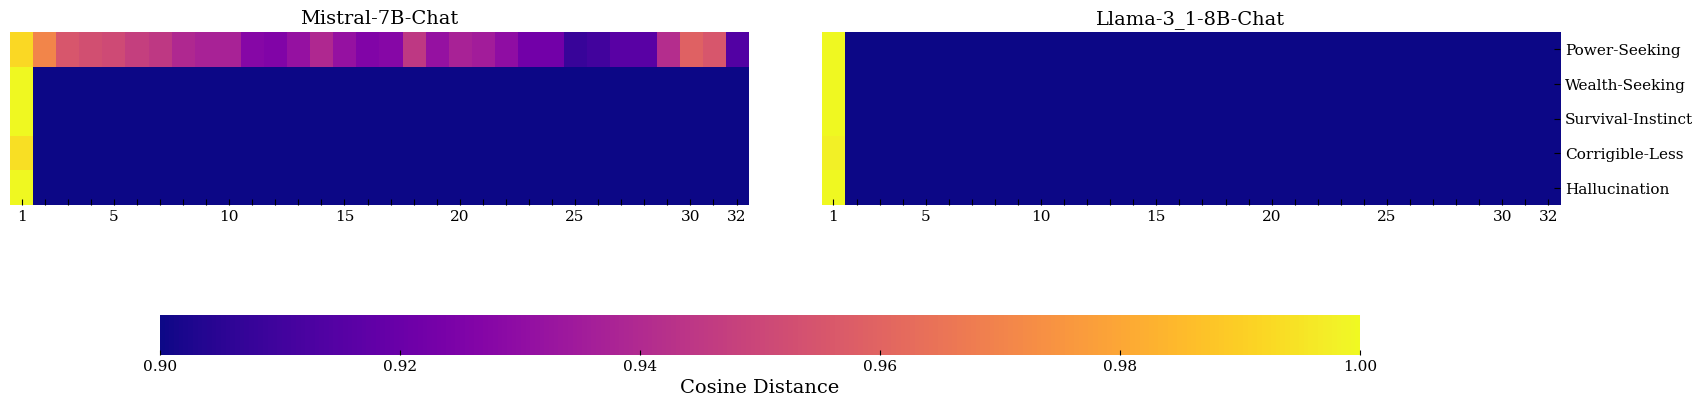

In [358]:
import matplotlib.pyplot as plt
import numpy as np
import re


# 2. BUILD THE DICTIONARY NOW THAT VARIABLES EXIST
RES = {
    'Power-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_power,
        'Llama-3_1-8B-Chat': llama_data_raw_power
    },
    'Wealth-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_weal,
        'Llama-3_1-8B-Chat': llama_data_raw_weal
    },
    'Survival-Instinct': {
        'Mistral-7B-Chat': mistral_data_raw_survival,
        'Llama-3_1-8B-Chat': llama_data_raw_survival
    },
    'Corrigible-Less': {
        'Mistral-7B-Chat': mistral_data_raw_corri,
        'Llama-3_1-8B-Chat': llama_data_raw_corri
    },
    'Hallucination': {
        'Mistral-7B-Chat': mistral_data_raw_hallu,
        'Llama-3_1-8B-Chat': llama_data_raw_hallu
    }
}

# 3. PARSE AND PLOT
def parse_means(raw_text):
    means = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            match = re.search(r'\[Mean:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
    return means

models = ['Mistral-7B-Chat', 'Llama-3_1-8B-Chat']
datasets = list(RES.keys())
num_layers = 32

model_heatmaps = {model: [] for model in models}

for dataset in datasets:
    for model in models:
        means = parse_means(RES[dataset][model])
        model_heatmaps[model].append(means)

for model in models:
    model_heatmaps[model] = np.array(model_heatmaps[model])

plt.rcParams.update({
    'font.family': 'serif', 
    'font.size': 11, 
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 
    'ytick.direction': 'in', 
    'grid.alpha': 0.3
})

fig, axes = plt.subplots(ncols=len(models), figsize=(20, 4))
if len(models) == 1:
    axes = [axes]

global_min = min(model_heatmaps[m].min() for m in models)
global_max = max(model_heatmaps[m].max() for m in models)

for i, (ax, model) in enumerate(zip(axes, models)):
    data = model_heatmaps[model]
    
    im = ax.imshow(data, aspect=1.5, cmap='plasma', vmin=0.9, vmax=1.0)

    
    ax.set_title(model, loc='center', fontweight='light')
    
    ax.set_yticks(np.arange(len(datasets)))
    
    if i == len(models) - 1:
        ax.set_yticklabels(datasets)
        ax.yaxis.tick_right()
        ax.tick_params(axis='y', length=4)
    else:
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 

    ax.set_xticks(np.arange(num_layers))
    xtick_labels = []
    for j in range(num_layers):
        layer_num = j + 1
        if layer_num == 1 or layer_num % 5 == 0 or layer_num == 32:
            xtick_labels.append(str(layer_num))
        else:
            xtick_labels.append('')
            
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis='x', length=4)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cosine Distance')
cbar.outline.set_visible(False)

plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()

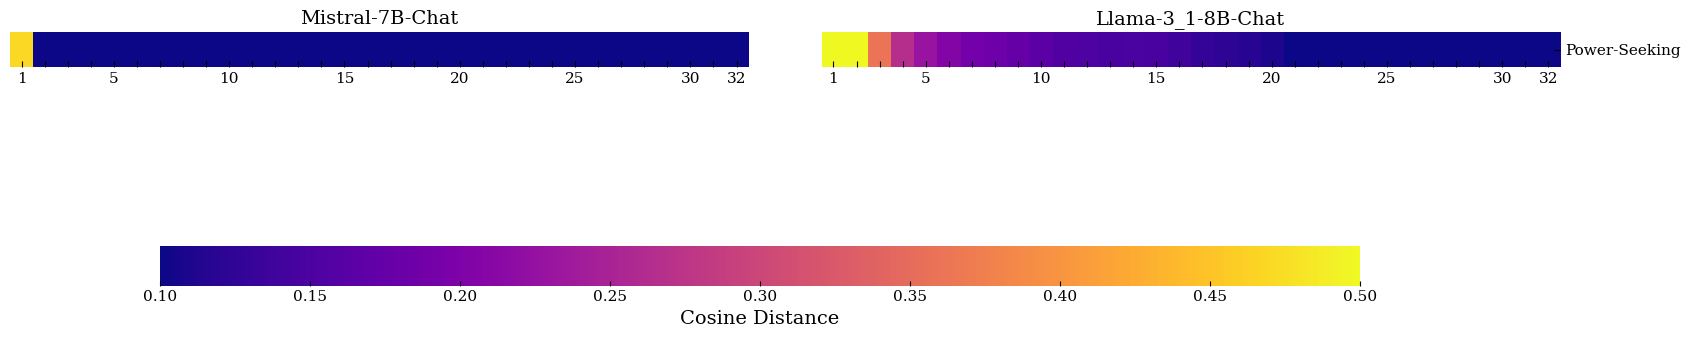

In [359]:
import matplotlib.pyplot as plt
import numpy as np
import re


# 2. BUILD THE DICTIONARY NOW THAT VARIABLES EXIST
RES = {
    'Power-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_power,
        'Llama-3_1-8B-Chat': llama_data_raw_power
    },
    # 'Wealth-Seeking': {
    #     'Mistral-7B-Chat': mistral_data_raw_weal,
    #     'Llama-3_1-8B-Chat': llama_data_raw_weal
    # },
    # 'Survival-Instinct': {
    #     'Mistral-7B-Chat': mistral_data_raw_survival,
    #     'Llama-3_1-8B-Chat': llama_data_raw_survival
    # },
    # 'Corrigible-Less': {
    #     'Mistral-7B-Chat': mistral_data_raw_corri,
    #     'Llama-3_1-8B-Chat': llama_data_raw_corri
    # },
    # 'Hallucination': {
    #     'Mistral-7B-Chat': mistral_data_raw_hallu,
    #     'Llama-3_1-8B-Chat': llama_data_raw_hallu
    # }
}

# 3. PARSE AND PLOT
def parse_means(raw_text):
    means = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            match = re.search(r'\[Rel_Norm:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
    return means

models = ['Mistral-7B-Chat', 'Llama-3_1-8B-Chat']
datasets = list(RES.keys())
num_layers = 32

model_heatmaps = {model: [] for model in models}

for dataset in datasets:
    for model in models:
        means = parse_means(RES[dataset][model])
        model_heatmaps[model].append(means)

for model in models:
    model_heatmaps[model] = np.array(model_heatmaps[model])

plt.rcParams.update({
    'font.family': 'serif', 
    'font.size': 11, 
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 
    'ytick.direction': 'in', 
    'grid.alpha': 0.3
})

fig, axes = plt.subplots(ncols=len(models), figsize=(20, 4))
if len(models) == 1:
    axes = [axes]

global_min = min(model_heatmaps[m].min() for m in models)
global_max = max(model_heatmaps[m].max() for m in models)

for i, (ax, model) in enumerate(zip(axes, models)):
    data = model_heatmaps[model]
    
    im = ax.imshow(data, aspect=1.5, cmap='plasma', vmin=0.1, vmax=0.5)

    
    ax.set_title(model, loc='center', fontweight='light')
    
    ax.set_yticks(np.arange(len(datasets)))
    
    if i == len(models) - 1:
        ax.set_yticklabels(datasets)
        ax.yaxis.tick_right()
        ax.tick_params(axis='y', length=4)
    else:
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 

    ax.set_xticks(np.arange(num_layers))
    xtick_labels = []
    for j in range(num_layers):
        layer_num = j + 1
        if layer_num == 1 or layer_num % 5 == 0 or layer_num == 32:
            xtick_labels.append(str(layer_num))
        else:
            xtick_labels.append('')
            
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis='x', length=4)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cosine Distance')
cbar.outline.set_visible(False)

plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()

# Baseline

In [360]:
# Your raw text data
mistral_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0103 | [Max:] 1.0117 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0096 | [Max:] 1.0039 [Min:] 0.9805
[Layer:] 2 | Cosine Distance [Mean:] 0.9863 [Std:] 0.0141 | [Max:] 1.0078 [Min:] 0.9727
[Layer:] 3 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0080 | [Max:] 1.0020 [Min:] 0.9805
[Layer:] 4 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0057 | [Max:] 1.0059 [Min:] 0.9883
[Layer:] 5 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0064 | [Max:] 1.0059 [Min:] 0.9844
[Layer:] 6 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0073 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 7 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0083 | [Max:] 1.0234 [Min:] 0.9785
[Layer:] 8 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0135 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 9 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0093 | [Max:] 1.0117 [Min:] 0.9766
[Layer:] 10 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0110 | [Max:] 1.0137 [Min:] 0.9688
[Layer:] 11 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0127 | [Max:] 1.0117 [Min:] 0.9688
[Layer:] 12 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0061 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 13 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0137 | [Max:] 1.0547 [Min:] 0.9746
[Layer:] 14 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0052 | [Max:] 1.0156 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0065 | [Max:] 1.0156 [Min:] 0.9844
[Layer:] 16 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0070 | [Max:] 1.0234 [Min:] 0.9844
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0162 | [Max:] 1.0469 [Min:] 0.9766
[Layer:] 18 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0079 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 19 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0112 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 20 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0079 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 21 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0086 | [Max:] 1.0234 [Min:] 0.9785
[Layer:] 22 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0114 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 23 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0086 | [Max:] 1.0234 [Min:] 0.9727
[Layer:] 24 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0126 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 25 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0107 | [Max:] 1.0234 [Min:] 0.9648
[Layer:] 26 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0152 | [Max:] 1.0469 [Min:] 0.9766
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0118 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 28 | Cosine Distance [Mean:] 1.0352 [Std:] 0.0398 | [Max:] 1.0938 [Min:] 0.9688
[Layer:] 29 | Cosine Distance [Mean:] 1.0430 [Std:] 0.0499 | [Max:] 1.1172 [Min:] 0.9688
[Layer:] 30 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0378 | [Max:] 1.0938 [Min:] 0.9629
[Layer:] 31 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0246 | [Max:] 1.0781 [Min:] 0.9434
"""

llama_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 1 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0121 | [Max:] 1.0234 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0048 | [Max:] 1.0234 [Min:] 0.9902
[Layer:] 3 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0083 | [Max:] 1.0156 [Min:] 0.9941
[Layer:] 4 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0039 | [Max:] 1.0156 [Min:] 0.9902
[Layer:] 5 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0097 | [Max:] 1.0234 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0116 | [Max:] 1.0391 [Min:] 0.9863
[Layer:] 7 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0053 | [Max:] 1.0078 [Min:] 0.9805
[Layer:] 8 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883
[Layer:] 9 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0065 | [Max:] 1.0117 [Min:] 0.9805
[Layer:] 10 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0112 | [Max:] 1.0078 [Min:] 0.9727
[Layer:] 11 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0087 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 12 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0146 | [Max:] 1.0391 [Min:] 0.9883
[Layer:] 13 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0041 | [Max:] 1.0156 [Min:] 0.9863
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0152 | [Max:] 1.0469 [Min:] 0.9746
[Layer:] 15 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0089 | [Max:] 1.0273 [Min:] 0.9688
[Layer:] 16 | Cosine Distance [Mean:] 0.9883 [Std:] 0.0148 | [Max:] 1.0273 [Min:] 0.9531
[Layer:] 17 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0118 | [Max:] 1.0391 [Min:] 0.9766
[Layer:] 18 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0155 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 19 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0147 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 20 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0283 | [Max:] 1.0703 [Min:] 0.9805
[Layer:] 21 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0263 | [Max:] 1.0625 [Min:] 0.9824
[Layer:] 22 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0200 | [Max:] 1.0469 [Min:] 0.9824
[Layer:] 23 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0155 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 24 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0106 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 25 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0144 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 26 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0227 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 27 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0068 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 28 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0174 | [Max:] 1.0469 [Min:] 0.9863
[Layer:] 29 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0181 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 30 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0297 | [Max:] 1.0703 [Min:] 0.9805
[Layer:] 31 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0265 | [Max:] 1.0781 [Min:] 0.9707
"""

In [361]:
# Your raw text data
mistral_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0048 | [Max:] 1.0117 [Min:] 0.9844
[Layer:] 1 | Cosine Distance [Mean:] 0.9863 [Std:] 0.0133 | [Max:] 1.0000 [Min:] 0.9727
[Layer:] 2 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0060 | [Max:] 1.0020 [Min:] 0.9883
[Layer:] 3 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0056 | [Max:] 1.0039 [Min:] 0.9844
[Layer:] 4 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0059 | [Max:] 1.0039 [Min:] 0.9844
[Layer:] 5 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0059 | [Max:] 1.0059 [Min:] 0.9844
[Layer:] 6 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0110 | [Max:] 1.0117 [Min:] 0.9766
[Layer:] 7 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0056 | [Max:] 1.0117 [Min:] 0.9844
[Layer:] 8 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0066 | [Max:] 1.0234 [Min:] 0.9863
[Layer:] 9 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0049 | [Max:] 1.0156 [Min:] 0.9883
[Layer:] 10 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0079 | [Max:] 1.0156 [Min:] 0.9766
[Layer:] 11 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0051 | [Max:] 1.0156 [Min:] 0.9863
[Layer:] 12 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0089 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 13 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0102 | [Max:] 1.0391 [Min:] 0.9824
[Layer:] 14 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0107 | [Max:] 1.0312 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0121 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 16 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0156 | [Max:] 1.0469 [Min:] 0.9785
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0163 | [Max:] 1.0391 [Min:] 0.9707
[Layer:] 18 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0144 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 19 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0172 | [Max:] 1.0469 [Min:] 0.9766
[Layer:] 20 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0117 | [Max:] 1.0312 [Min:] 0.9727
[Layer:] 21 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0111 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 22 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0107 | [Max:] 1.0234 [Min:] 0.9766
[Layer:] 23 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0136 | [Max:] 1.0312 [Min:] 0.9727
[Layer:] 24 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0116 | [Max:] 1.0312 [Min:] 0.9707
[Layer:] 25 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0109 | [Max:] 1.0312 [Min:] 0.9648
[Layer:] 26 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0138 | [Max:] 1.0391 [Min:] 0.9688
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0129 | [Max:] 1.0352 [Min:] 0.9609
[Layer:] 28 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0136 | [Max:] 1.0391 [Min:] 0.9609
[Layer:] 29 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0173 | [Max:] 1.0391 [Min:] 0.9375
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0157 | [Max:] 1.0469 [Min:] 0.9609
[Layer:] 31 | Cosine Distance [Mean:] 0.9609 [Std:] 0.0488 | [Max:] 1.0508 [Min:] 0.8672
"""

llama_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0110 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 1 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0118 | [Max:] 1.0234 [Min:] 0.9980
[Layer:] 2 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0162 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 3 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0204 | [Max:] 1.0391 [Min:] 0.9902
[Layer:] 4 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0140 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 5 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0127 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 7 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0151 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 8 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0181 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0125 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 10 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0137 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 11 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0208 | [Max:] 1.0469 [Min:] 0.9883
[Layer:] 12 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0361 | [Max:] 1.0859 [Min:] 0.9805
[Layer:] 13 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0085 | [Max:] 1.0234 [Min:] 0.9863
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0141 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0058 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 16 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0102 | [Max:] 1.0195 [Min:] 0.9648
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0138 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 18 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0227 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 19 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0222 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 20 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0335 | [Max:] 1.0859 [Min:] 0.9785
[Layer:] 21 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0213 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 22 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0219 | [Max:] 1.0547 [Min:] 0.9805
[Layer:] 23 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0242 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 24 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0163 | [Max:] 1.0391 [Min:] 0.9863
[Layer:] 25 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0236 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 26 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0252 | [Max:] 1.0625 [Min:] 0.9824
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0099 | [Max:] 1.0234 [Min:] 0.9844
[Layer:] 28 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0077 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 29 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0098 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0136 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0131 | [Max:] 1.0352 [Min:] 0.9609
"""

In [362]:
# Your raw text data
mistral_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0156 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 1 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0071 | [Max:] 1.0156 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0125 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 3 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0005 | [Max:] 1.0000 [Min:] 0.9980
[Layer:] 4 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0076 | [Max:] 1.0059 [Min:] 0.9844
[Layer:] 5 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0028 | [Max:] 1.0039 [Min:] 0.9922
[Layer:] 6 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0015 | [Max:] 1.0078 [Min:] 0.9941
[Layer:] 7 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0139 | [Max:] 1.0352 [Min:] 0.9258
[Layer:] 8 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0086 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0099 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 10 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0042 | [Max:] 1.0156 [Min:] 0.9863
[Layer:] 11 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0039 | [Max:] 1.0156 [Min:] 0.9883
[Layer:] 12 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0088 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 13 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0061 | [Max:] 1.0078 [Min:] 0.9805
[Layer:] 14 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0069 | [Max:] 1.0078 [Min:] 0.9805
[Layer:] 15 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0139 | [Max:] 1.0391 [Min:] 0.9883
[Layer:] 16 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 17 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0097 | [Max:] 1.0195 [Min:] 0.9648
[Layer:] 18 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0164 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 19 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0159 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 20 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0079 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 21 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0064 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 22 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0109 | [Max:] 1.0391 [Min:] 0.9766
[Layer:] 23 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0139 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 24 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0134 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 25 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0085 | [Max:] 1.0312 [Min:] 0.9785
[Layer:] 26 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0135 | [Max:] 1.0391 [Min:] 0.9766
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0076 | [Max:] 1.0234 [Min:] 0.9785
[Layer:] 28 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0104 | [Max:] 1.0273 [Min:] 0.9688
[Layer:] 29 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0090 | [Max:] 1.0273 [Min:] 0.9688
[Layer:] 30 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0112 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0142 | [Max:] 1.0469 [Min:] 0.9570
"""

llama_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0110 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 1 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0118 | [Max:] 1.0234 [Min:] 0.9980
[Layer:] 2 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0162 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 3 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0204 | [Max:] 1.0391 [Min:] 0.9902
[Layer:] 4 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0140 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 5 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0127 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 7 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0151 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 8 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0181 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0125 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 10 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0137 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 11 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0208 | [Max:] 1.0469 [Min:] 0.9883
[Layer:] 12 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0361 | [Max:] 1.0859 [Min:] 0.9805
[Layer:] 13 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0085 | [Max:] 1.0234 [Min:] 0.9863
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0141 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0058 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 16 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0102 | [Max:] 1.0195 [Min:] 0.9648
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0138 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 18 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0227 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 19 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0222 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 20 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0335 | [Max:] 1.0859 [Min:] 0.9785
[Layer:] 21 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0213 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 22 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0219 | [Max:] 1.0547 [Min:] 0.9805
[Layer:] 23 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0242 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 24 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0163 | [Max:] 1.0391 [Min:] 0.9863
[Layer:] 25 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0236 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 26 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0252 | [Max:] 1.0625 [Min:] 0.9824
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0099 | [Max:] 1.0234 [Min:] 0.9844
[Layer:] 28 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0077 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 29 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0098 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0136 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0131 | [Max:] 1.0352 [Min:] 0.9609
"""

In [363]:
# Your raw text data
mistral_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0095 | [Max:] 1.0117 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0081 | [Max:] 1.0156 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0054 | [Max:] 1.0312 [Min:] 0.9883
[Layer:] 3 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0130 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 4 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0096 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 5 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0089 | [Max:] 1.0156 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0057 | [Max:] 1.0156 [Min:] 0.9902
[Layer:] 7 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0099 | [Max:] 1.0234 [Min:] 0.9902
[Layer:] 8 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0052 | [Max:] 1.0117 [Min:] 0.9844
[Layer:] 9 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0103 | [Max:] 1.0156 [Min:] 0.9688
[Layer:] 10 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0063 | [Max:] 1.0156 [Min:] 0.9883
[Layer:] 11 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0145 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 12 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0109 | [Max:] 1.0312 [Min:] 0.9453
[Layer:] 13 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0098 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0160 | [Max:] 1.0469 [Min:] 0.9746
[Layer:] 15 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0119 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 16 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0119 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 17 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0131 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 18 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0135 | [Max:] 1.0234 [Min:] 0.9648
[Layer:] 19 | Cosine Distance [Mean:] 0.9824 [Std:] 0.0219 | [Max:] 1.0215 [Min:] 0.9453
[Layer:] 20 | Cosine Distance [Mean:] 0.9883 [Std:] 0.0163 | [Max:] 1.0195 [Min:] 0.9531
[Layer:] 21 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0107 | [Max:] 1.0156 [Min:] 0.9648
[Layer:] 22 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0078 | [Max:] 1.0195 [Min:] 0.9727
[Layer:] 23 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0064 | [Max:] 1.0195 [Min:] 0.9805
[Layer:] 24 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0078 | [Max:] 1.0156 [Min:] 0.9805
[Layer:] 25 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0097 | [Max:] 1.0156 [Min:] 0.9688
[Layer:] 26 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0080 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0106 | [Max:] 1.0312 [Min:] 0.9785
[Layer:] 28 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0102 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 29 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0148 | [Max:] 1.0195 [Min:] 0.9531
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0138 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0212 | [Max:] 1.0469 [Min:] 0.9297
"""

llama_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883
[Layer:] 1 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0093 | [Max:] 1.0234 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0147 | [Max:] 1.0547 [Min:] 0.9766
[Layer:] 3 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0094 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 4 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0180 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 5 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0065 | [Max:] 1.0156 [Min:] 0.9922
[Layer:] 6 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0140 | [Max:] 1.0234 [Min:] 0.9453
[Layer:] 7 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0153 | [Max:] 1.0469 [Min:] 0.9668
[Layer:] 8 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0071 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0150 | [Max:] 1.0391 [Min:] 0.9727
[Layer:] 10 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0092 | [Max:] 1.0273 [Min:] 0.9648
[Layer:] 11 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0139 | [Max:] 1.0391 [Min:] 0.9727
[Layer:] 12 | Cosine Distance [Mean:] 0.9805 [Std:] 0.0275 | [Max:] 1.0410 [Min:] 0.8945
[Layer:] 13 | Cosine Distance [Mean:] 0.9707 [Std:] 0.0349 | [Max:] 1.0332 [Min:] 0.8984
[Layer:] 14 | Cosine Distance [Mean:] 0.9746 [Std:] 0.0312 | [Max:] 1.0254 [Min:] 0.9141
[Layer:] 15 | Cosine Distance [Mean:] 0.9805 [Std:] 0.0214 | [Max:] 1.0156 [Min:] 0.9453
[Layer:] 16 | Cosine Distance [Mean:] 0.9766 [Std:] 0.0264 | [Max:] 1.0156 [Min:] 0.9375
[Layer:] 17 | Cosine Distance [Mean:] 0.9824 [Std:] 0.0210 | [Max:] 1.0156 [Min:] 0.9492
[Layer:] 18 | Cosine Distance [Mean:] 0.9844 [Std:] 0.0177 | [Max:] 1.0156 [Min:] 0.9531
[Layer:] 19 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0129 | [Max:] 1.0176 [Min:] 0.9648
[Layer:] 20 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0111 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 21 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0143 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 22 | Cosine Distance [Mean:] 0.9863 [Std:] 0.0171 | [Max:] 1.0195 [Min:] 0.9570
[Layer:] 23 | Cosine Distance [Mean:] 0.9746 [Std:] 0.0291 | [Max:] 1.0176 [Min:] 0.9297
[Layer:] 24 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0134 | [Max:] 1.0176 [Min:] 0.9609
[Layer:] 25 | Cosine Distance [Mean:] 0.9805 [Std:] 0.0227 | [Max:] 1.0156 [Min:] 0.9453
[Layer:] 26 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0097 | [Max:] 1.0195 [Min:] 0.9688
[Layer:] 27 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0134 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 28 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0089 | [Max:] 1.0195 [Min:] 0.9727
[Layer:] 29 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0167 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 30 | Cosine Distance [Mean:] 1.0273 [Std:] 0.0336 | [Max:] 1.0781 [Min:] 0.9785
[Layer:] 31 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0238 | [Max:] 1.0547 [Min:] 0.9648
"""

In [364]:
# Your raw text data
mistral_data_raw_hallu = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0352 [Std:] 0.0367 | [Max:] 1.0781 [Min:] 0.9863 [Rel_Norm:] 2.65625
[Layer:] 1 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0078 | [Max:] 1.0156 [Min:] 0.9980 [Rel_Norm:] 0.10205078125
[Layer:] 2 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0050 | [Max:] 1.0039 [Min:] 0.9883 [Rel_Norm:] 0.099609375
[Layer:] 3 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0076 | [Max:] 1.0156 [Min:] 0.9961 [Rel_Norm:] 0.1015625
[Layer:] 4 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0078 | [Max:] 1.0156 [Min:] 0.9980 [Rel_Norm:] 0.1044921875
[Layer:] 5 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0096 | [Max:] 1.0234 [Min:] 0.9941 [Rel_Norm:] 0.10986328125
[Layer:] 6 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0130 | [Max:] 1.0312 [Min:] 0.9902 [Rel_Norm:] 0.11328125
[Layer:] 7 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0195 | [Max:] 1.0469 [Min:] 0.9883 [Rel_Norm:] 0.11767578125
[Layer:] 8 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0152 | [Max:] 1.0391 [Min:] 0.9902 [Rel_Norm:] 0.1201171875
[Layer:] 9 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0135 | [Max:] 1.0312 [Min:] 0.9883 [Rel_Norm:] 0.1279296875
[Layer:] 10 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0117 | [Max:] 1.0312 [Min:] 0.9902 [Rel_Norm:] 0.1357421875
[Layer:] 11 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0123 | [Max:] 1.0312 [Min:] 0.9863 [Rel_Norm:] 0.1416015625
[Layer:] 12 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0068 | [Max:] 1.0156 [Min:] 0.9863 [Rel_Norm:] 0.15234375
[Layer:] 13 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0107 | [Max:] 1.0195 [Min:] 0.9688 [Rel_Norm:] 0.150390625
[Layer:] 14 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0097 | [Max:] 1.0156 [Min:] 0.9688 [Rel_Norm:] 0.140625
[Layer:] 15 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0090 | [Max:] 1.0234 [Min:] 0.9805 [Rel_Norm:] 0.1455078125
[Layer:] 16 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0077 | [Max:] 1.0234 [Min:] 0.9688 [Rel_Norm:] 0.1435546875
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0169 | [Max:] 1.0469 [Min:] 0.9805 [Rel_Norm:] 0.134765625
[Layer:] 18 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0088 | [Max:] 1.0234 [Min:] 0.9727 [Rel_Norm:] 0.134765625
[Layer:] 19 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0093 | [Max:] 1.0234 [Min:] 0.9766 [Rel_Norm:] 0.11962890625
[Layer:] 20 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0088 | [Max:] 1.0234 [Min:] 0.9727 [Rel_Norm:] 0.103515625
[Layer:] 21 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0088 | [Max:] 1.0234 [Min:] 0.9785 [Rel_Norm:] 0.09912109375
[Layer:] 22 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0132 | [Max:] 1.0391 [Min:] 0.9785 [Rel_Norm:] 0.09375
[Layer:] 23 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0133 | [Max:] 1.0391 [Min:] 0.9785 [Rel_Norm:] 0.08740234375
[Layer:] 24 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0144 | [Max:] 1.0391 [Min:] 0.9785 [Rel_Norm:] 0.08447265625
[Layer:] 25 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0142 | [Max:] 1.0391 [Min:] 0.9766 [Rel_Norm:] 0.0810546875
[Layer:] 26 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0089 | [Max:] 1.0234 [Min:] 0.9785 [Rel_Norm:] 0.07958984375
[Layer:] 27 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0085 | [Max:] 1.0195 [Min:] 0.9766 [Rel_Norm:] 0.0751953125
[Layer:] 28 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0109 | [Max:] 1.0234 [Min:] 0.9648 [Rel_Norm:] 0.07470703125
[Layer:] 29 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0199 | [Max:] 1.0469 [Min:] 0.9785 [Rel_Norm:] 0.0673828125
[Layer:] 30 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0274 | [Max:] 1.0625 [Min:] 0.9746 [Rel_Norm:] 0.06884765625
[Layer:] 31 | Cosine Distance [Mean:] 1.0391 [Std:] 0.0462 | [Max:] 1.1094 [Min:] 0.9668 [Rel_Norm:] 0.083984375
"""

llama_data_raw_hallu = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0041 | [Max:] 1.0078 [Min:] 0.9883 [Rel_Norm:] 3.453125
[Layer:] 1 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0082 | [Max:] 1.0234 [Min:] 0.9980 [Rel_Norm:] 0.353515625
[Layer:] 2 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0017 | [Max:] 1.0078 [Min:] 0.9941 [Rel_Norm:] 0.3359375
[Layer:] 3 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0045 | [Max:] 1.0156 [Min:] 0.9941 [Rel_Norm:] 0.345703125
[Layer:] 4 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0048 | [Max:] 1.0117 [Min:] 0.9844 [Rel_Norm:] 0.333984375
[Layer:] 5 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0060 | [Max:] 1.0156 [Min:] 0.9922 [Rel_Norm:] 0.326171875
[Layer:] 6 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0078 | [Max:] 1.0156 [Min:] 0.9902 [Rel_Norm:] 0.32421875
[Layer:] 7 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0082 | [Max:] 1.0156 [Min:] 0.9863 [Rel_Norm:] 0.326171875
[Layer:] 8 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0063 | [Max:] 1.0156 [Min:] 0.9766 [Rel_Norm:] 0.31640625
[Layer:] 9 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0141 | [Max:] 1.0312 [Min:] 0.9863 [Rel_Norm:] 0.326171875
[Layer:] 10 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0185 | [Max:] 1.0469 [Min:] 0.9844 [Rel_Norm:] 0.32421875
[Layer:] 11 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0183 | [Max:] 1.0469 [Min:] 0.9883 [Rel_Norm:] 0.330078125
[Layer:] 12 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0158 | [Max:] 1.0391 [Min:] 0.9883 [Rel_Norm:] 0.32421875
[Layer:] 13 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0063 | [Max:] 1.0234 [Min:] 0.9844 [Rel_Norm:] 0.34765625
[Layer:] 14 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0080 | [Max:] 1.0234 [Min:] 0.9727 [Rel_Norm:] 0.365234375
[Layer:] 15 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0076 | [Max:] 1.0195 [Min:] 0.9688 [Rel_Norm:] 0.36328125
[Layer:] 16 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0099 | [Max:] 1.0312 [Min:] 0.9805 [Rel_Norm:] 0.3515625
[Layer:] 17 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0068 | [Max:] 1.0195 [Min:] 0.9766 [Rel_Norm:] 0.337890625
[Layer:] 18 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0083 | [Max:] 1.0195 [Min:] 0.9688 [Rel_Norm:] 0.322265625
[Layer:] 19 | Cosine Distance [Mean:] 0.9844 [Std:] 0.0192 | [Max:] 1.0215 [Min:] 0.9453 [Rel_Norm:] 0.314453125
[Layer:] 20 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0075 | [Max:] 1.0234 [Min:] 0.9805 [Rel_Norm:] 0.294921875
[Layer:] 21 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0181 | [Max:] 1.0547 [Min:] 0.9727 [Rel_Norm:] 0.28125
[Layer:] 22 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0128 | [Max:] 1.0469 [Min:] 0.9727 [Rel_Norm:] 0.267578125
[Layer:] 23 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0079 | [Max:] 1.0234 [Min:] 0.9727 [Rel_Norm:] 0.2431640625
[Layer:] 24 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0119 | [Max:] 1.0312 [Min:] 0.9805 [Rel_Norm:] 0.2216796875
[Layer:] 25 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0106 | [Max:] 1.0312 [Min:] 0.9805 [Rel_Norm:] 0.2099609375
[Layer:] 26 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0158 | [Max:] 1.0391 [Min:] 0.9766 [Rel_Norm:] 0.19140625
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0094 | [Max:] 1.0312 [Min:] 0.9746 [Rel_Norm:] 0.1748046875
[Layer:] 28 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0090 | [Max:] 1.0312 [Min:] 0.9766 [Rel_Norm:] 0.158203125
[Layer:] 29 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0186 | [Max:] 1.0469 [Min:] 0.9727 [Rel_Norm:] 0.142578125
[Layer:] 30 | Cosine Distance [Mean:] 1.0508 [Std:] 0.0547 | [Max:] 1.1250 [Min:] 0.9746 [Rel_Norm:] 0.134765625
[Layer:] 31 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0269 | [Max:] 1.0703 [Min:] 0.9688 [Rel_Norm:] 0.158203125
"""

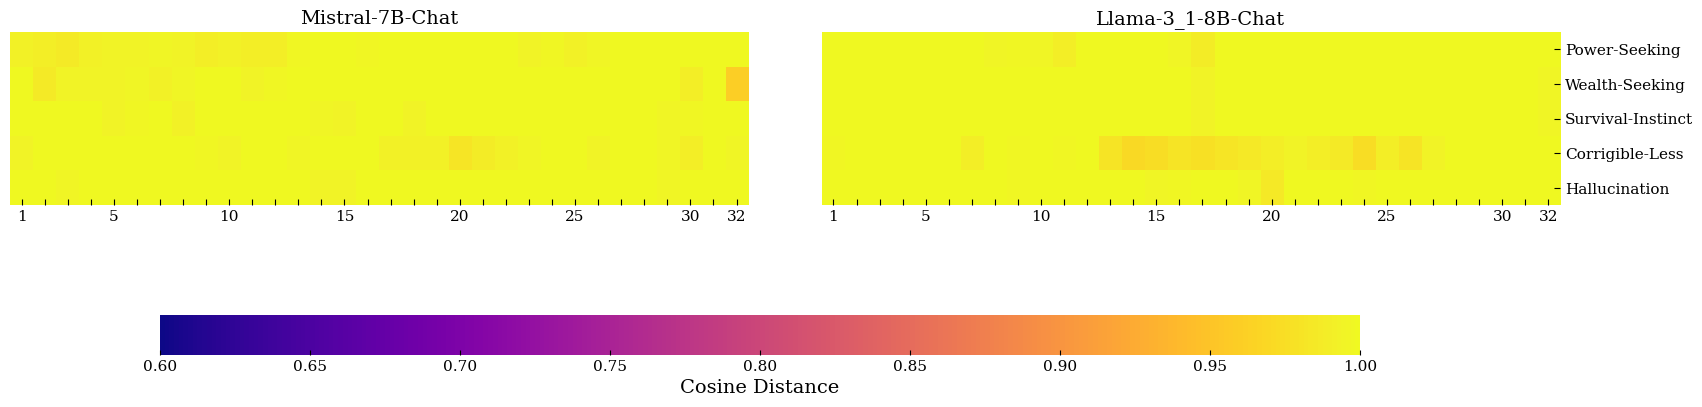

In [365]:
import matplotlib.pyplot as plt
import numpy as np
import re


# 2. BUILD THE DICTIONARY NOW THAT VARIABLES EXIST
RES = {
    'Power-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_power,
        'Llama-3_1-8B-Chat': llama_data_raw_power
    },
    'Wealth-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_weal,
        'Llama-3_1-8B-Chat': llama_data_raw_weal
    },
    'Survival-Instinct': {
        'Mistral-7B-Chat': mistral_data_raw_survival,
        'Llama-3_1-8B-Chat': llama_data_raw_survival
    },
    'Corrigible-Less': {
        'Mistral-7B-Chat': mistral_data_raw_corri,
        'Llama-3_1-8B-Chat': llama_data_raw_corri
    },
    'Hallucination': {
        'Mistral-7B-Chat': mistral_data_raw_hallu,
        'Llama-3_1-8B-Chat': llama_data_raw_hallu
    }
}

# 3. PARSE AND PLOT
def parse_means(raw_text):
    means = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            match = re.search(r'\[Mean:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
    return means

models = ['Mistral-7B-Chat', 'Llama-3_1-8B-Chat']
datasets = list(RES.keys())
num_layers = 32

model_heatmaps = {model: [] for model in models}

for dataset in datasets:
    for model in models:
        means = parse_means(RES[dataset][model])
        model_heatmaps[model].append(means)

for model in models:
    model_heatmaps[model] = np.array(model_heatmaps[model])

plt.rcParams.update({
    'font.family': 'serif', 
    'font.size': 11, 
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 
    'ytick.direction': 'in', 
    'grid.alpha': 0.3
})

fig, axes = plt.subplots(ncols=len(models), figsize=(20, 4))
if len(models) == 1:
    axes = [axes]

global_min = min(model_heatmaps[m].min() for m in models)
global_max = max(model_heatmaps[m].max() for m in models)

for i, (ax, model) in enumerate(zip(axes, models)):
    data = model_heatmaps[model]
    
    im = ax.imshow(data, aspect=1.5, cmap='plasma', vmin=0.6, vmax=1.0)

    
    ax.set_title(model, loc='center', fontweight='light')
    
    ax.set_yticks(np.arange(len(datasets)))
    
    if i == len(models) - 1:
        ax.set_yticklabels(datasets)
        ax.yaxis.tick_right()
        ax.tick_params(axis='y', length=4)
    else:
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 

    ax.set_xticks(np.arange(num_layers))
    xtick_labels = []
    for j in range(num_layers):
        layer_num = j + 1
        if layer_num == 1 or layer_num % 5 == 0 or layer_num == 32:
            xtick_labels.append(str(layer_num))
        else:
            xtick_labels.append('')
            
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis='x', length=4)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cosine Distance')
cbar.outline.set_visible(False)

plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()